So I found this dataset that has the LaLiga matches from 2019 to 2025, it has 6 seasons of data available and I will use it to predict the 2025-2026 LaLiga matches and the winner.

This code is to ignore warnings, especially from pandas.

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marcelbiezunski/laliga-matches-dataset-2019-2025-fbref")

print("Path to dataset files:", path)

df = pd.read_csv(path + '/matches_full.csv')

100%|██████████| 137k/137k [00:00<00:00, 40.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/marcelbiezunski/laliga-matches-dataset-2019-2025-fbref/versions/1


Now that we have the dataset let's inspect it and see which transformations we could do to make it better and find the best model for this data. First we have to see how many columns and the name of the columns that we have to see what is available.

In [4]:
display(df.shape)
display(df.columns)

(4318, 29)

Index(['Unnamed: 0', 'date', 'time', 'comp', 'round', 'day', 'venue', 'result',
       'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain',
       'formation', 'opp formation', 'referee', 'match report', 'notes', 'sh',
       'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team'],
      dtype='object')

Let's clean up a little bit the dataset and see what is missing.

In [5]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

So we are supposed to have 6 seasons of data, and there are 20 teams in each season and here we have matches repeated, so we have like the home and away version of every season, so we should have 38 games per team per season, which means there should be 38 * 20 * 6 = 4560 rows of data, which is not true because the shape of the dataframe says that there are 4318 rows, we are missing about 200 games, so let's see how many matches we have for each team. So to see where are the matches missing, we will use the season column and see how many rows do we have for each season to see which season has the missing matches.

In [6]:
df['season'].value_counts()

,count
season,
2024,760
2023,760
2021,760
2022,760
2020,760
2025,518


The last season is the one that has missing data, but it's okay, now let's see if there are missing values.

In [7]:
df.isnull().sum()

,0
date,0
time,0
comp,0
round,0
day,0
venue,0
result,0
gf,0
ga,0
opponent,0


Attendance and notes are the two columns with missing values and these are columns that are not important to be honest, so let's drop them, on the other side, the referee and the dist column can be useful so let's leave it like that for the moment and then when creating the model we will see how we deal with it.

In [8]:
df = df.drop(['attendance', 'notes'], axis=1)

In [9]:
df.head()

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,referee,match report,sh,sot,dist,fk,pk,pkatt,season,team
0,2024-08-17,21:30,La Liga,Matchweek 1,Sat,Away,W,2.0,1.0,Valencia,...,NaN,Match Report,17.0,5.0,18.6,1.0,1,1,2025,Barcelona
1,2024-08-24,19:00,La Liga,Matchweek 2,Sat,Home,W,2.0,1.0,Athletic Club,...,NaN,Match Report,13.0,5.0,16.6,0.0,0,0,2025,Barcelona
2,2024-08-27,21:30,La Liga,Matchweek 3,Tue,Away,W,2.0,1.0,Rayo Vallecano,...,NaN,Match Report,22.0,5.0,19.3,1.0,0,0,2025,Barcelona
3,2024-08-31,17:00,La Liga,Matchweek 4,Sat,Home,W,7.0,0.0,Valladolid,...,Isidro Díaz de Mera,Match Report,23.0,11.0,13.7,1.0,0,0,2025,Barcelona
4,2024-09-15,16:15,La Liga,Matchweek 5,Sun,Away,W,4.0,1.0,Girona,...,Alejandro Muñíz,Match Report,20.0,9.0,19.1,0.0,0,0,2025,Barcelona


Now when cleaning we have to understand which columns are and aren't useful for visualizations and predictions, for example comp is not useful because we already know that we're analyzing LaLiga, we will also drop the captain column because there are a lot of captains that already retired or they don't even play for those teams now. The next column that will be dropped is the match report one because it doesn't have information.

In [10]:
df = df.drop(['captain', 'comp', 'match report'], axis=1)

Now, before moving on with the machine learning prediction it is good to make some data visualization and also get some key stats from the datasets. Let's start by getting the teams that scored more goals by season and also the teams that received more goals by season. For this we will create some functions and then plot it just to not repeat ourselves.

In [11]:
def get_goals_stats(dataframe, most, conceded):                    # The arguments are first the dataframe, then if you want the most and then if you want the conceded.

    seasons = sorted(df['season'].unique().tolist())               # Get all the seasons in order.
    goals_df = {}                                                  # Create a dictionary to store each season and top 5 teams.

    if conceded:
        goals_a = dataframe.groupby(['season', 'team'])['ga'].sum()  # Grouping by the season and team and getting the goals conceded if the user specified it in the function.

        if most:
            for s in seasons:                                                                     # Iterating over all the seasons sorted create a key on the dictionary
                goals_df[f'season_{s}'] = goals_a.loc[s,:].sort_values(ascending=False)[0:5]      # that stores the team and the goals conceded or scored based on what you specified
                                                                                                  # on the function, that is basically what the rest of the code does, it iterates over
            return goals_df                                                                       # all the seasons and just adds the information to the key assigned.
        else:
            for s in seasons:
                goals_df[f'season_{s}'] = goals_a.loc[s,:].sort_values(ascending=True)[0:5]

            return goals_df

    else:
        goals_f = dataframe.groupby(['season', 'team'])['gf'].sum()

        if most:
            for s in seasons:
                goals_df[f'season_{s}'] = goals_f.loc[s,:].sort_values(ascending=False)[0:5]

            return goals_df
        else:
            for s in seasons:
                goals_df[f'season_{s}'] = goals_f.loc[s,:].sort_values(ascending=True)[0:5]

            return goals_df


def plot_goals(data, name):                          # From the get_goals_stats function we get the dictionary needed to make a bar plot

    if isinstance(data, dict):
        print(f'----------------------------------------------------------------------------------------------------\n')
        print(f'                                   {name.upper()}                                                         ')
        print('___________________________________________________________________________________________________\n')

        for s, data in data.items():            # This iterates over all the keys and values of the dictionaries and uses the indexes or the
                                                # team names as the X label and the goals scored or conceded as the Y label or Y data
            plt.figure(figsize=(9, 4))
            plt.bar(data.index, data.values)
            plt.title(f'Season {int(s[7:]) -1}-{s[7:]}')
            plt.xlabel('Teams')
            plt.ylabel('Goals')
            plt.show()

    else:
        return 'The function argument must be a dictionary'

def plot_ranking(data, name):   # This function also takes a dictionary as data for then ploting a ranking showing which teams has the most appearences
                                # On the list, here the same as above, the team goes on the X axis and the appearences on the Y axis.
    Count = {}
                                # All the data goes to the Count dictionary and here we don't care about the season just about the count or times the
    for k in data:              # team has appeared on the list.
        for k2 in data[k].index:
            if k2 in Count:
                Count[k2] += 1
            else:
                Count[k2] = 1

    Count = dict(sorted(Count.items(), key=lambda item: item[1], reverse=True)) # Here we sort the dictionary to have the keys with the most counts first
                                                                                # the key is using the lambda to specify that we want to sort by the values
    plt.figure(figsize=(18, 4))
    plt.bar(Count.keys(), Count.values())
    plt.title(name)
    plt.xlabel('Teams')
    plt.ylabel('Appearences')
    plt.show()

Now after creating this functions we will plot them.

----------------------------------------------------------------------------------------------------

                                   TEAMS WITH THE MOST GOALS SCORED                                                         
___________________________________________________________________________________________________



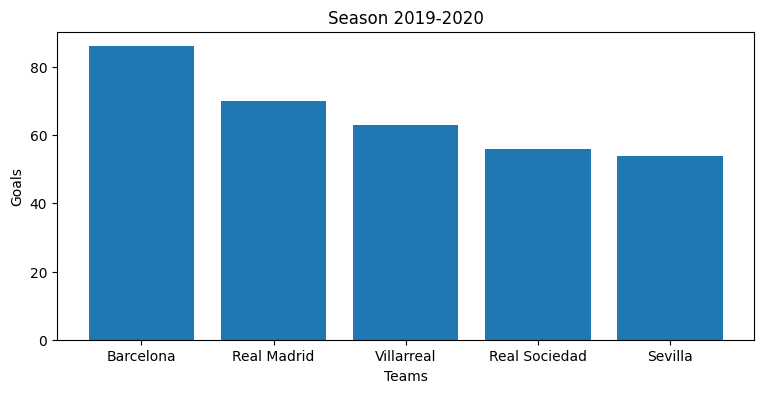

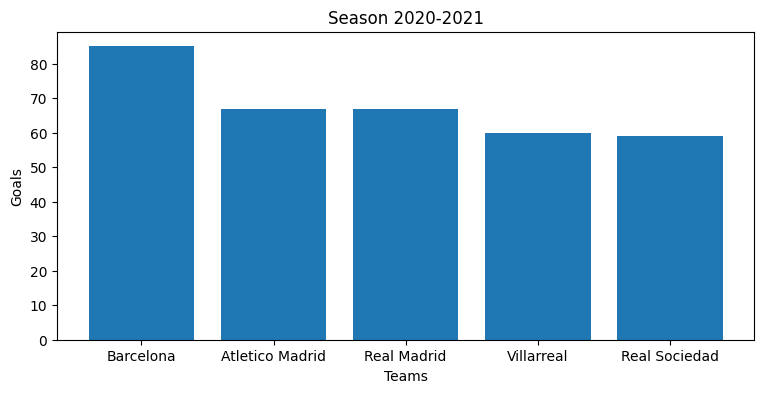

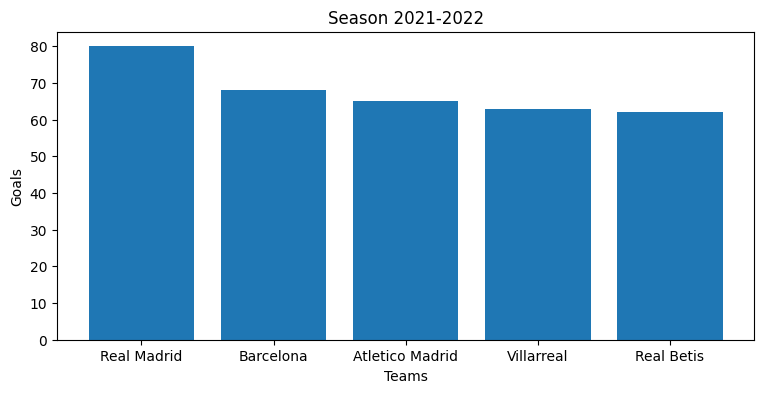

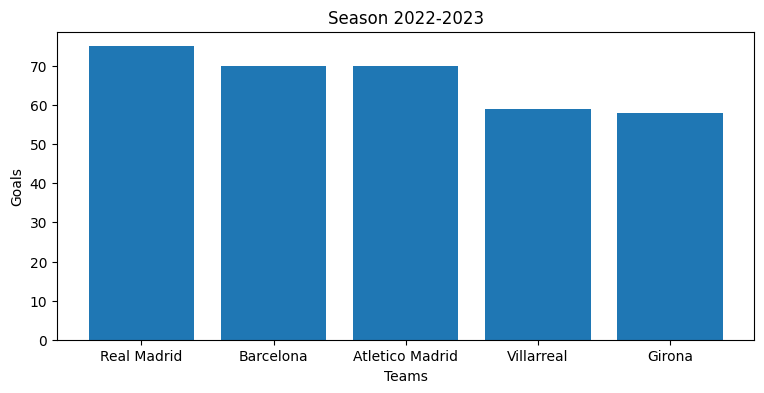

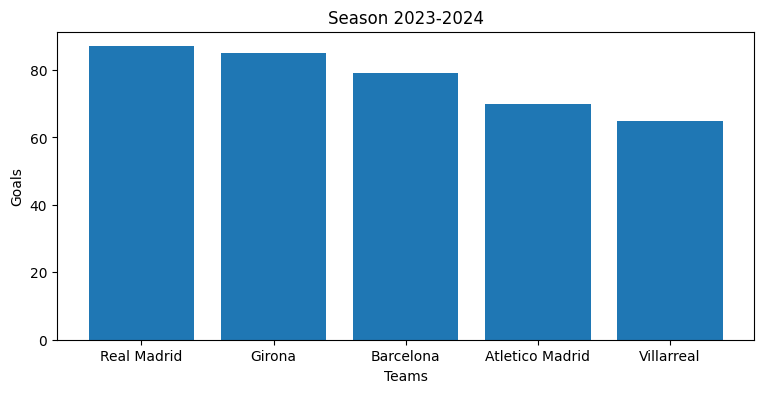

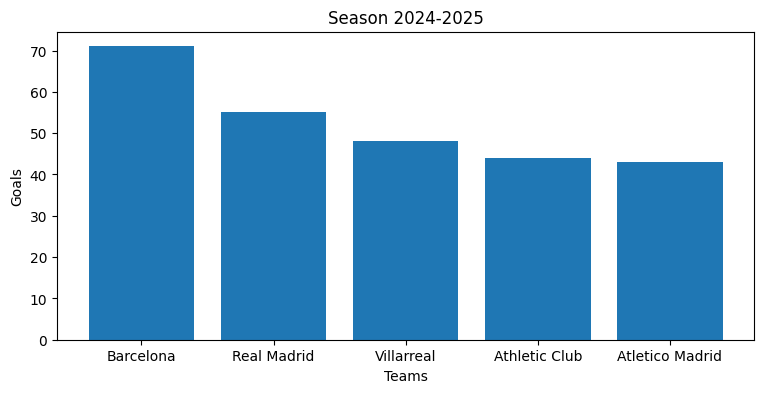

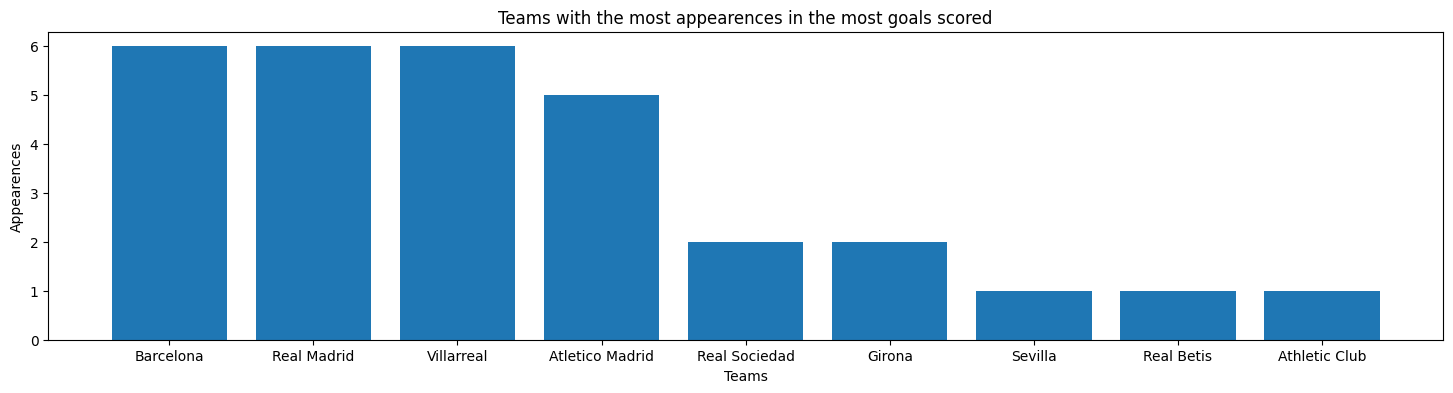

In [12]:
most_goals_f_df = get_goals_stats(df, most=True, conceded=False)
plot_goals(most_goals_f_df, 'Teams with the most goals scored')
print()
plot_ranking(most_goals_f_df, 'Teams with the most appearences in the most goals scored')

----------------------------------------------------------------------------------------------------

                                   TEAMS WITH THE LEAST GOALS CONCEDED                                                         
___________________________________________________________________________________________________



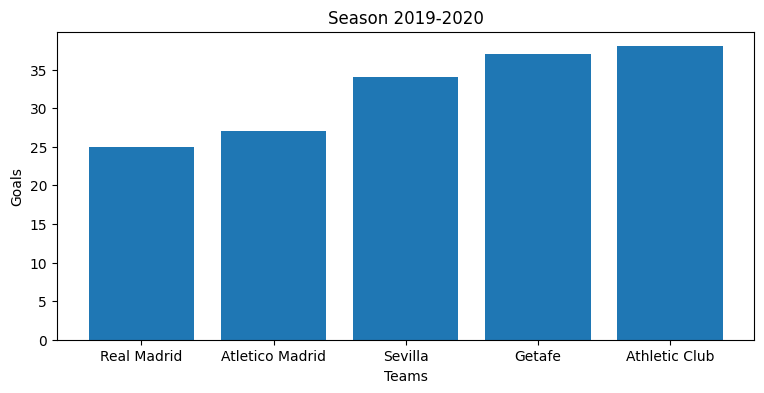

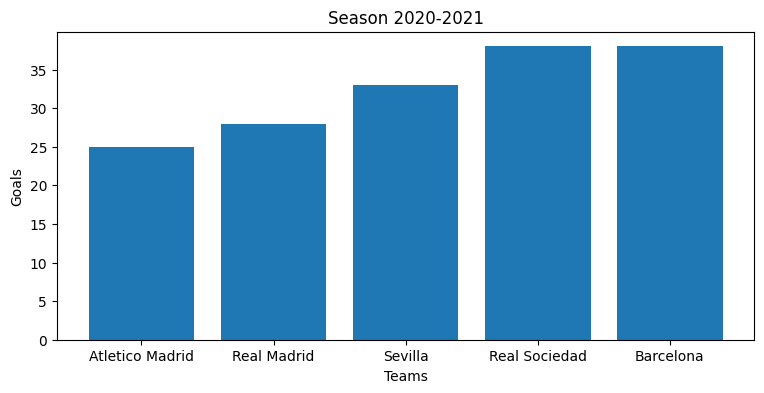

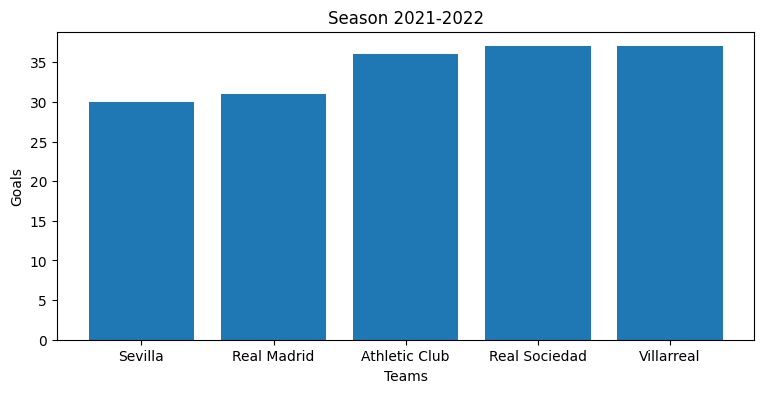

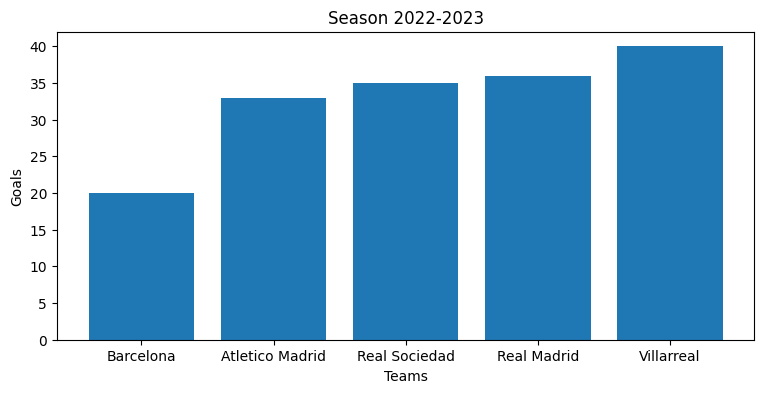

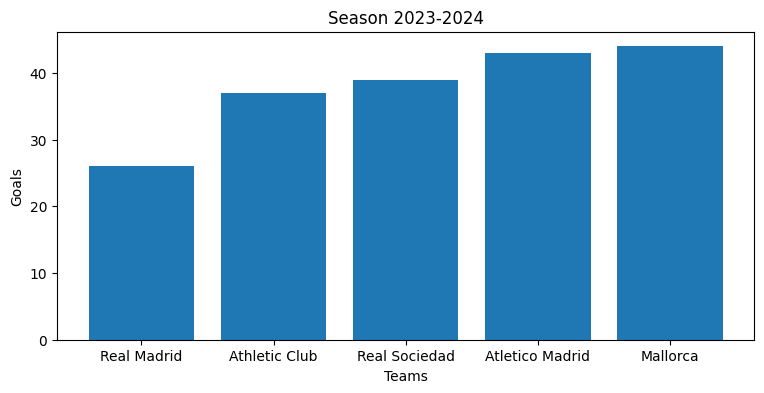

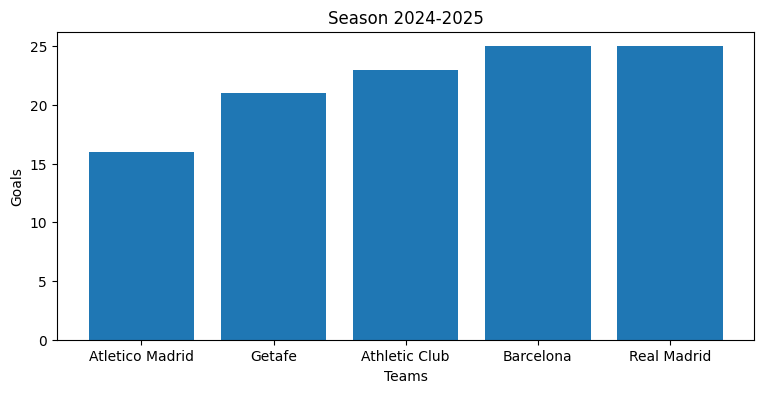

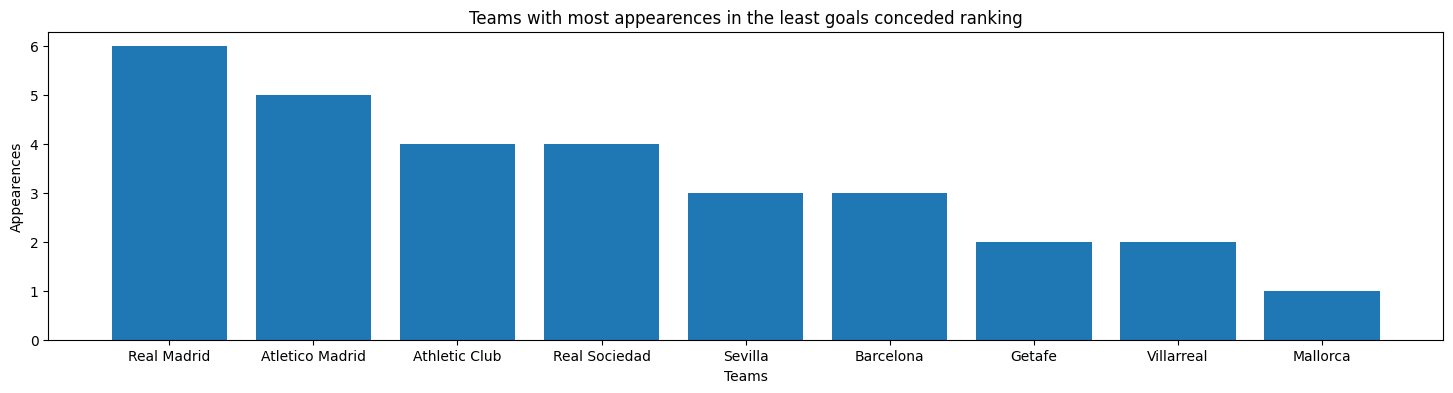

In [13]:
least_goals_a_df = get_goals_stats(df, most=False, conceded=True)
plot_goals(least_goals_a_df, 'Teams with the least goals conceded')
print()
plot_ranking(least_goals_a_df, 'Teams with most appearences in the least goals conceded ranking')

----------------------------------------------------------------------------------------------------

                                   TEAMS WITH THE LEAST GOALS SCORED                                                         
___________________________________________________________________________________________________



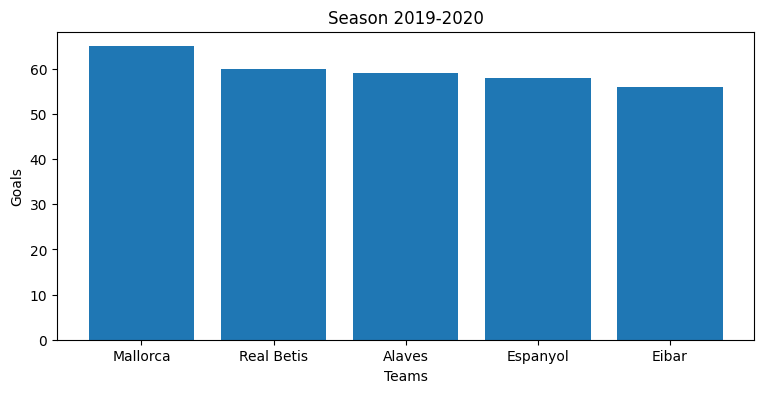

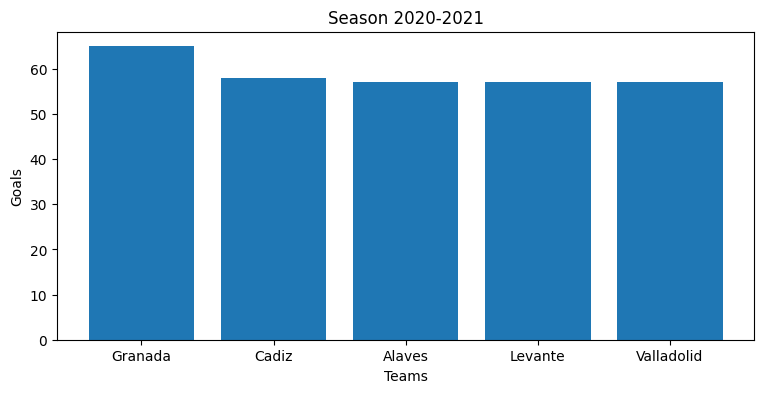

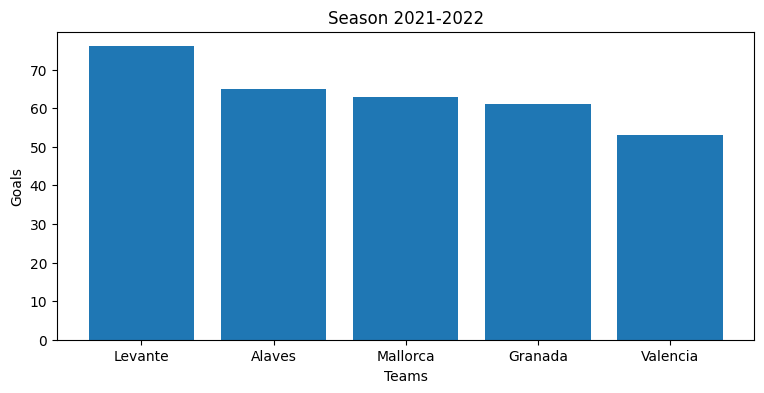

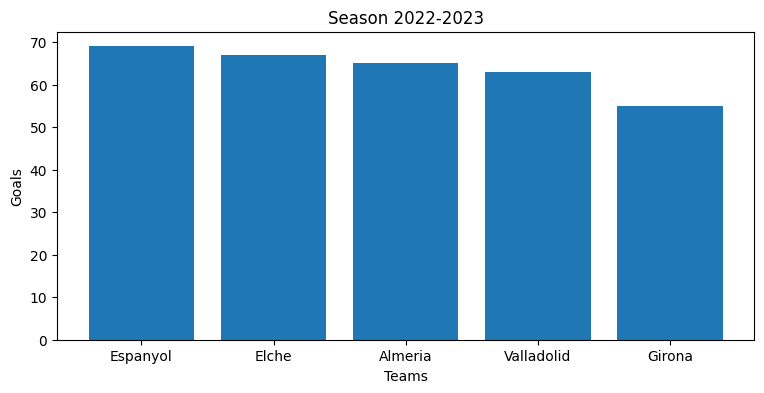

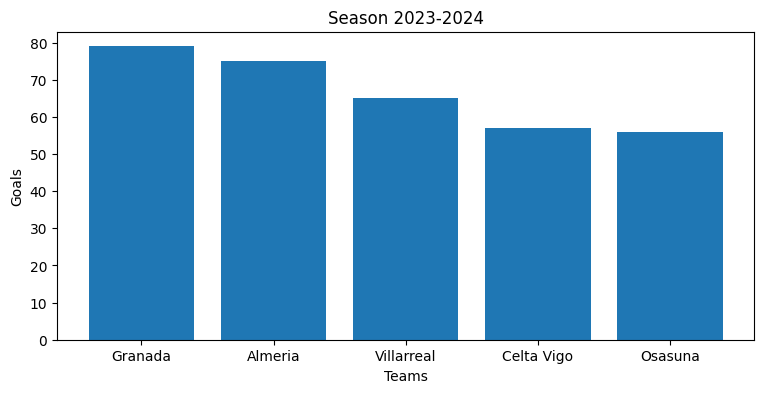

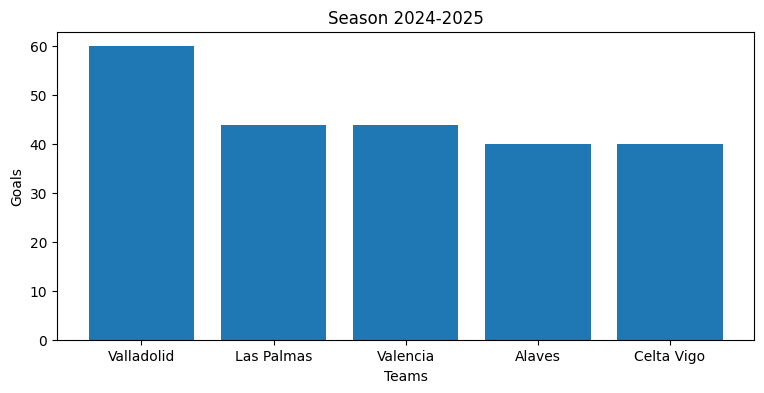

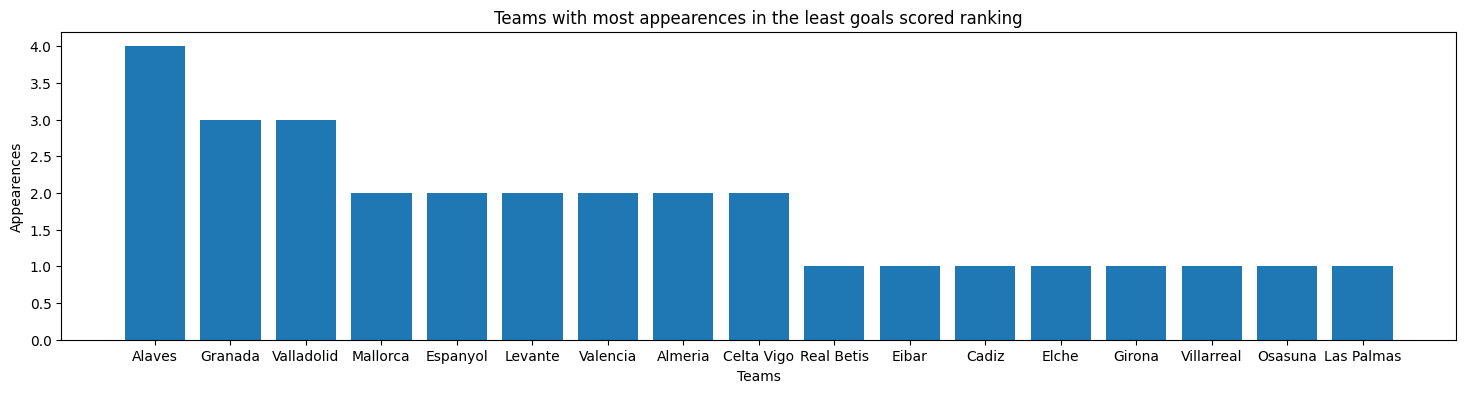

In [14]:
least_goals_f_df = get_goals_stats(df, most=True, conceded=True)
plot_goals(least_goals_f_df, 'Teams with the least goals scored')
print()
plot_ranking(least_goals_f_df, 'Teams with most appearences in the least goals scored ranking')

----------------------------------------------------------------------------------------------------

                                   TEAMS WITH THE MOST GOALS CONCEDED                                                         
___________________________________________________________________________________________________



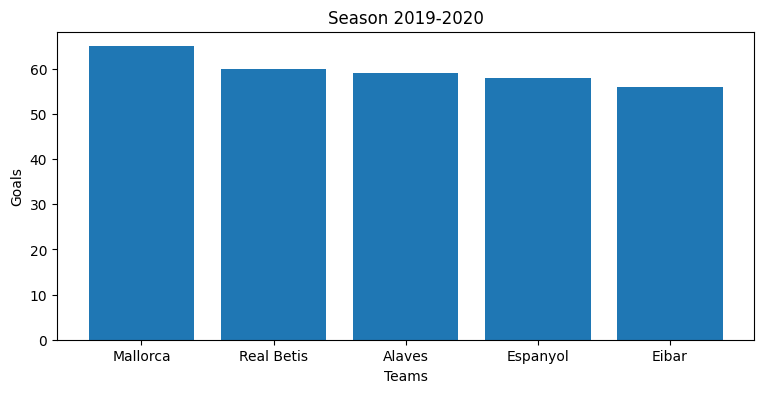

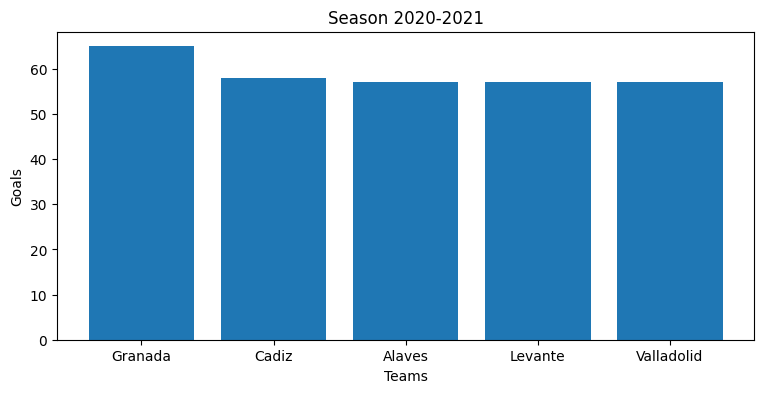

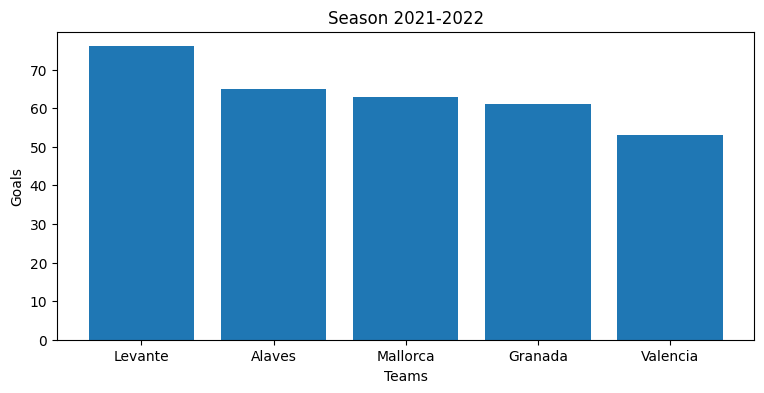

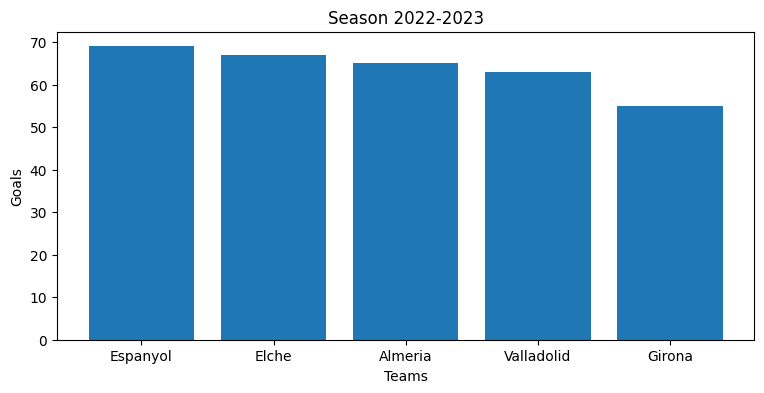

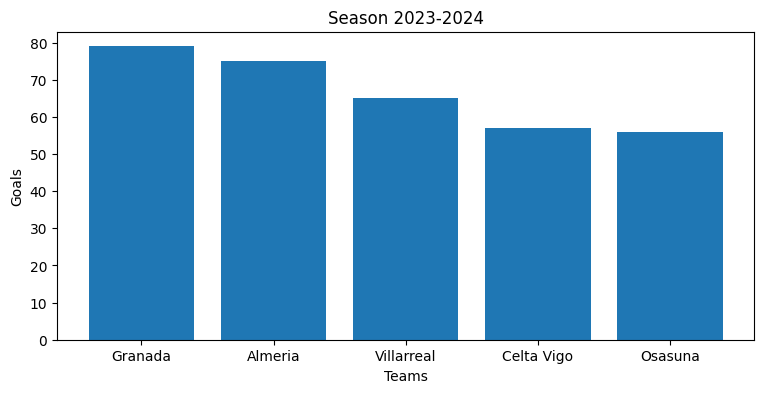

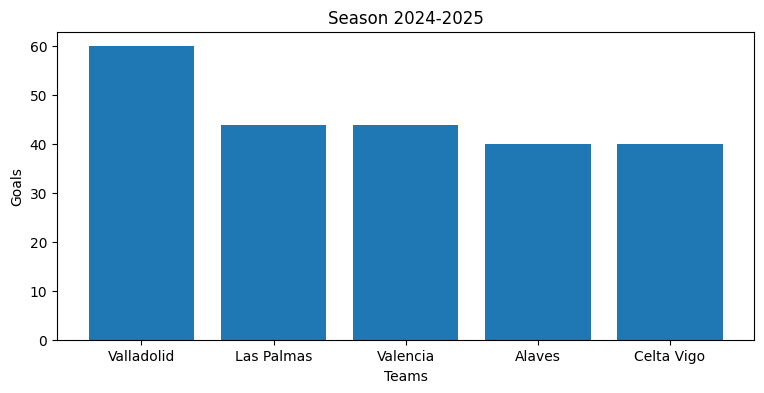

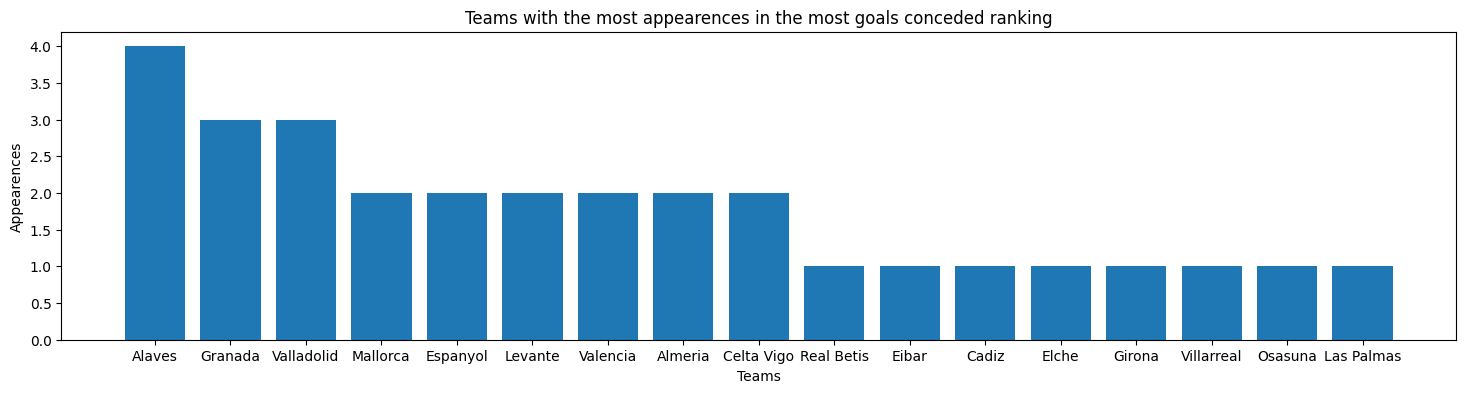

In [15]:
most_goals_a_df = get_goals_stats(df, most=True, conceded=True)
plot_goals(most_goals_a_df, 'Teams with the most goals conceded')
print()
plot_ranking(most_goals_a_df, 'Teams with the most appearences in the most goals conceded ranking')

Now, there is always controversy with the referees and the teams, so let's see the most repeated referees for any teams (I will use a function for just for the user to put the team he wants)

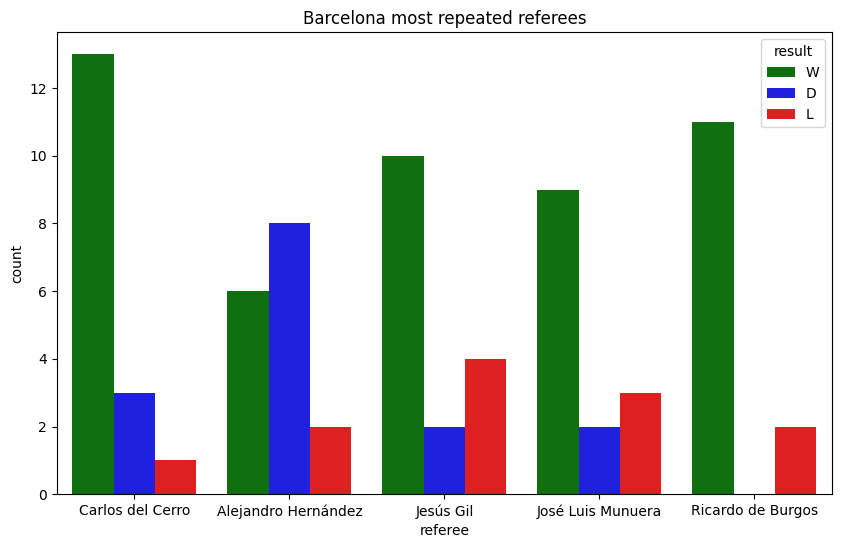

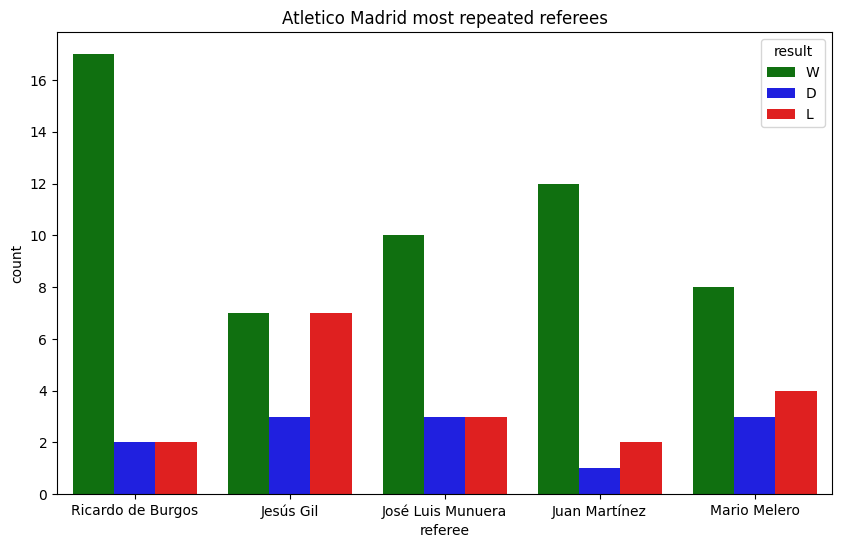

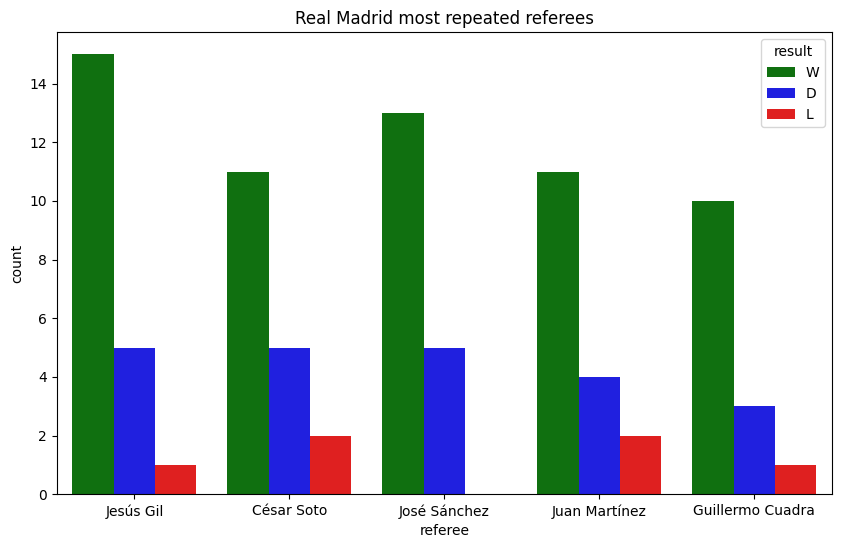

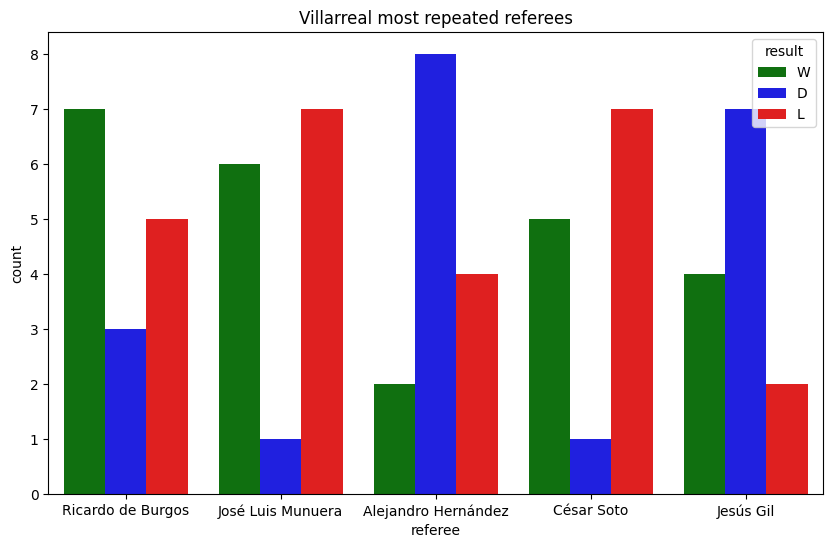

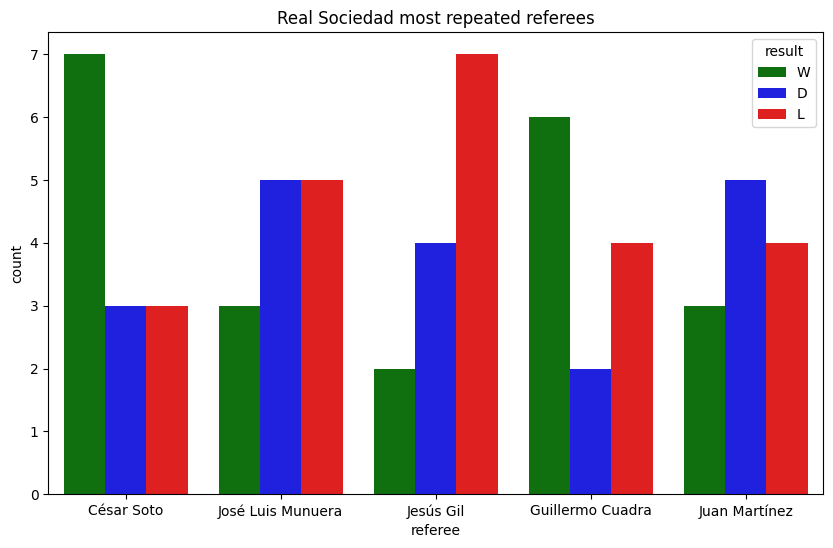

In [16]:
def get_referee_counts(data:pd.DataFrame, amount:int, *teams:str):

    if not teams:
        'You must give one team'

    teams_data = data['team'].unique().tolist()

    for team in teams:
        if team not in teams_data:
            print(f'Team was not founded, look for it here:\n{teams_data}')
            return

    # This function take the arguments data, different teams and the amount on the ranking
    # you want to see, let's say you want to see the top 3 or whatever, that is what you specify
    # on the amount, this is the preprocessing for then plotting the data. the return of this
    # function is a dataset showing each referee and how many draws, wins and losses.

    refereedf = data.groupby('team')[['referee', 'result']].value_counts().unstack().fillna(0)
    refereedf['total'] = refereedf.sum(axis=1)
    referee_data = {team: 0 for team in teams}

    for team in teams:
        team_df = refereedf.loc[team].sort_values(by='total', ascending=False)
        team_data = team_df[0:amount]
        referee_data[team] = team_data

    # for k, v in referee_data.items():
    #     print(k, '\n')                     UNCOMMENT THIS IF YOU WANT TO SEE THE DATAFRAME
    #     display(v)

    return referee_data

def plot_referee(data:dict):

    # Now, to plot the dataframe we have to make some changes,
    # We have to unpivot the table and basically put the name and
    # count of win, losses and draws by referee, so we use melt to
    # change from pivot table to normal table.

    if not isinstance(data, dict):
        return 'Data may be a dictionary'

    for k, v in data.items():
        v = v[['D', 'W', 'L']].reset_index()
        v = v[0:5]
        v = v.melt(id_vars='referee', value_vars=['W', 'D', 'L'], var_name='result', value_name='count')
        plt.figure(figsize=(10, 6))
        plt.title(f'{k} most repeated referees')
        sns.barplot(data=v, x='referee', y='count', hue='result', palette=['green', 'blue', 'red'])
        plt.show()


referee_data = get_referee_counts(df, 5, 'Barcelona', 'Atletico Madrid', 'Real Madrid', 'Villarreal', 'Real Sociedad')
plot_referee(referee_data)

And just to add some more spice, we can see which are the teams that had the most penalties and free kicks awarded.

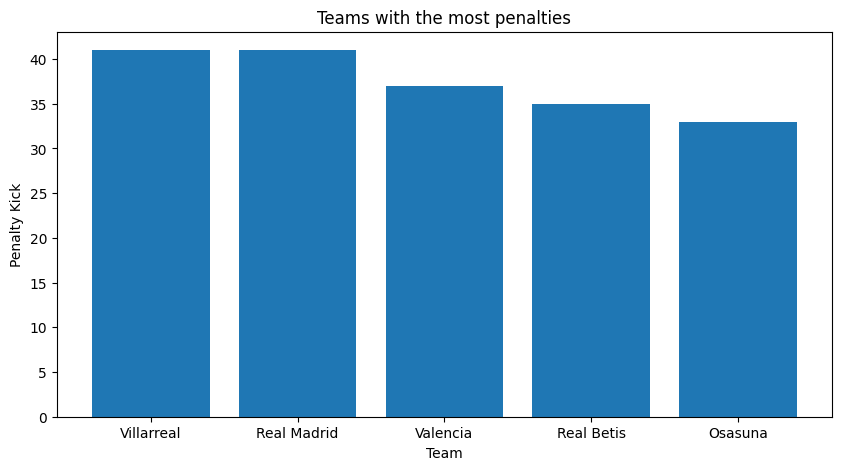

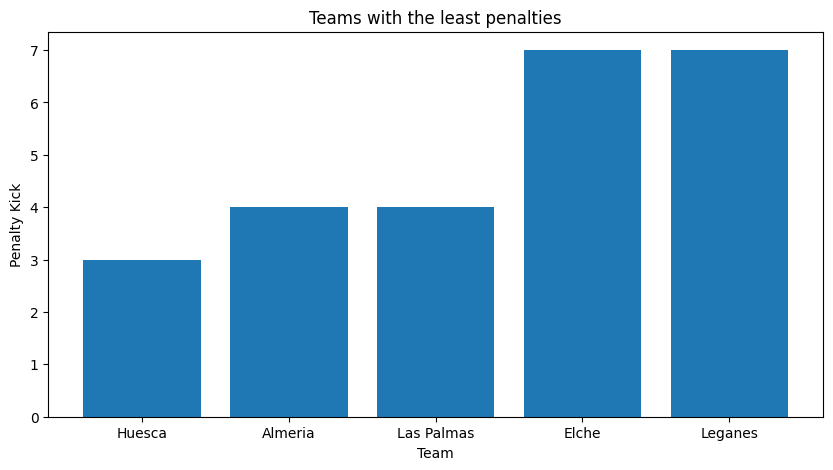

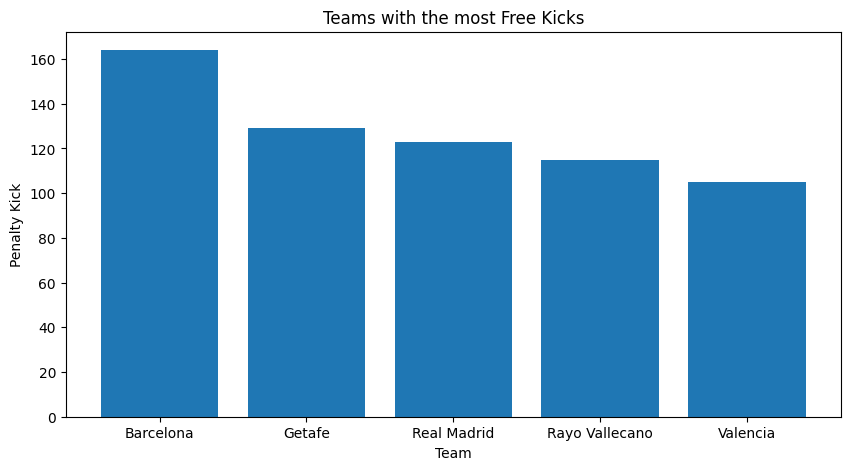

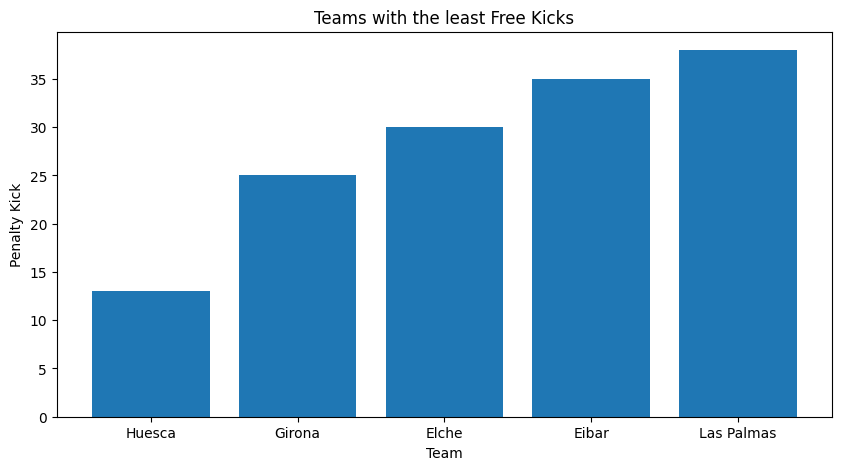

In [17]:
def penalty_freekicks(data: pd.DataFrame, penalty: bool, freekick: bool, ascending:bool, amount: int):

    # This function will get the data and if you specified penalty or freekick
    # it will do that, then the amount of teams you want to see or will be displayed
    # on the ranking.

    if penalty:
        if ascending:
            return data.groupby('team')['pk'].sum().reset_index().sort_values(by='pk', ascending=True)[0:amount]
        else:
            return data.groupby('team')['pk'].sum().reset_index().sort_values(by='pk', ascending=False)[0:amount]


    else:
        if ascending:
            return data.groupby('team')['fk'].sum().reset_index().sort_values(by='fk', ascending=True)[0:amount]
        else:
            return data.groupby('team')['fk'].sum().reset_index().sort_values(by='fk', ascending=False)[0:amount]

def plot_penalty_freekicks(data, title, penalty, fk):

    # This function will plot the data returned from the last function

    if penalty and not fk:
        y = 'pk'
    elif not penalty and fk:
        y = 'fk'
    else:
        'Specify between fk and pk'

    print()
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.bar(x=data['team'], height=data[y])
    plt.xlabel('Team')
    plt.ylabel('Penalty Kick')
    plt.show()
    print()


most_penalties = penalty_freekicks(df, True, False, False, 5)
least_penalties = penalty_freekicks(df, True, False, True, 5)
most_fks = penalty_freekicks(df, False, True, False, 5)
least_fks = penalty_freekicks(df, False, True, True, 5)

plot_penalty_freekicks(most_penalties, 'Teams with the most penalties',True, False)
plot_penalty_freekicks(least_penalties, 'Teams with the least penalties', True, False)
plot_penalty_freekicks(most_fks, 'Teams with the most Free Kicks', False, True)
plot_penalty_freekicks(least_fks, 'Teams with the least Free Kicks', False, True)

Now we can do the basic most wins and most losses in total, just to see which of the best teams has won the most games during this 6 years and the worst teams on this last 6 years.

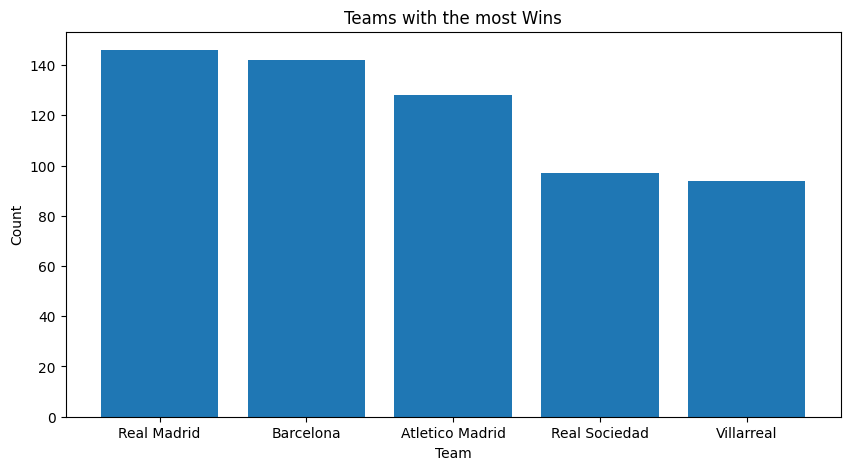

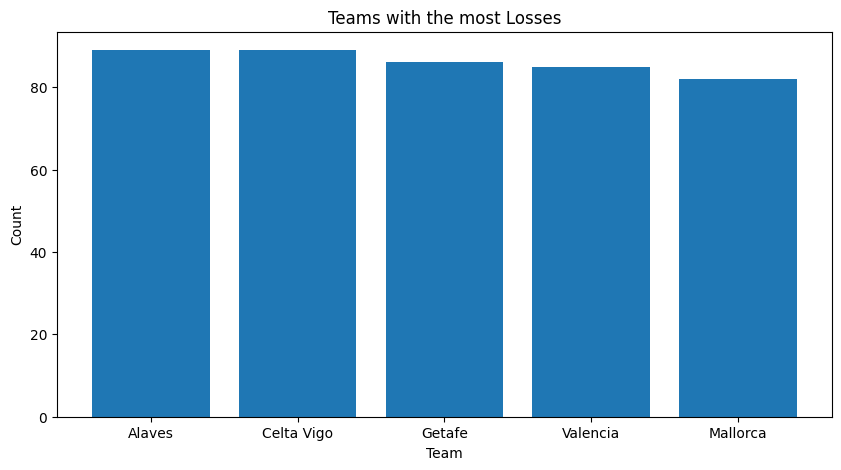

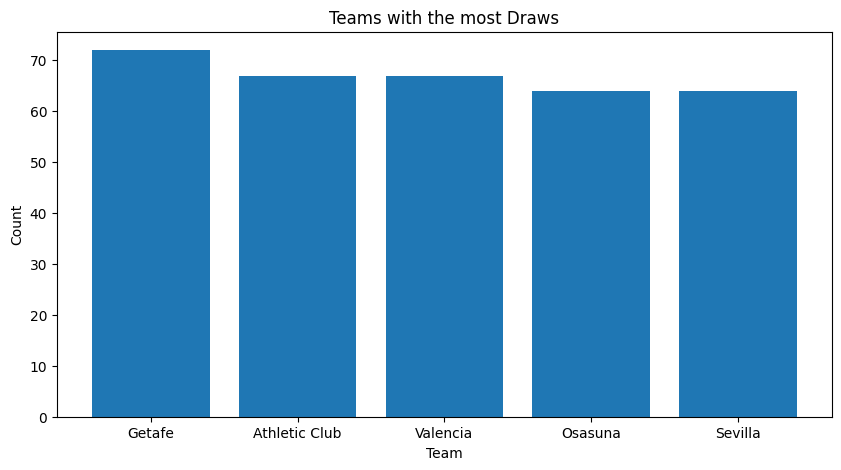

In [18]:
def get_wins_losses(data: pd.DataFrame, Wins: bool, Losses: bool, Draws: bool, amount: int):

    # The amount argument is for plotting the amount of teams you want to see
    # with the most wins, losses or draws, this function is pretty straight forward
    # The W, L and D are just boolean values, just put True on the one you want to be returned

    if Wins:
        result_data = data.groupby('team')['result'].value_counts().reset_index()
        result_data = result_data[result_data['result'] == 'W'].sort_values(by='count', ascending=False)
        return result_data[0:amount]

    elif Losses:
        result_data = data.groupby('team')['result'].value_counts().reset_index()
        result_data = result_data[result_data['result'] == 'L'].sort_values(by='count', ascending=False)
        return result_data[0:amount]

    else:
        result_data = data.groupby('team')['result'].value_counts().reset_index()
        result_data = result_data[result_data['result'] == 'D'].sort_values(by='count', ascending=False)
        return result_data[0:amount]

def plot_wins_losses(data: pd.DataFrame, title: str):

    # This function is for ploting what the last function returned
    print()
    plt.figure(figsize=(10, 5))
    plt.bar(x=data['team'], height=data['count'])
    plt.xlabel('Team')
    plt.ylabel('Count')
    plt.title(title)
    plt.show()
    print()

Wins = get_wins_losses(df, True, False, False, 5)
Losses = get_wins_losses(df, False, True, False, 5)
Draws = get_wins_losses(df, False, False, True, 5)
plot_wins_losses(Wins, 'Teams with the most Wins')
plot_wins_losses(Losses, 'Teams with the most Losses')
plot_wins_losses(Draws, 'Teams with the most Draws')

Now let's go with the in game stats, let's calculate the average of xg (Expected goals) and poss (Ball possesion) for each team and find out which are the best and worst, we can also do this with sh (shots), sot (shots on target)

In [19]:
df.columns

Index(['date', 'time', 'round', 'day', 'venue', 'result', 'gf', 'ga',
       'opponent', 'xg', 'xga', 'poss', 'formation', 'opp formation',
       'referee', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team'],
      dtype='object')

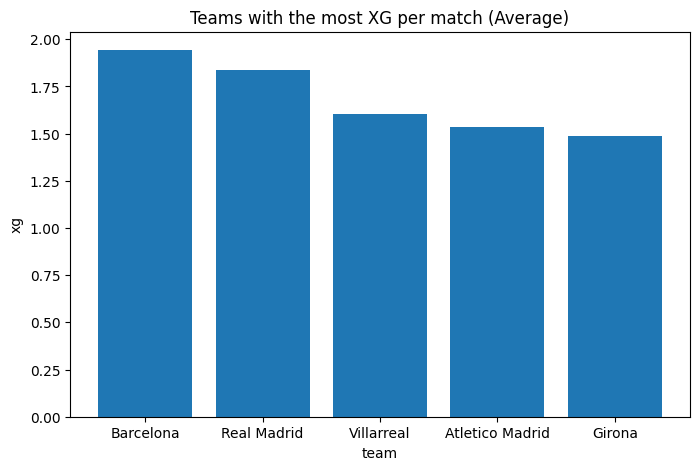

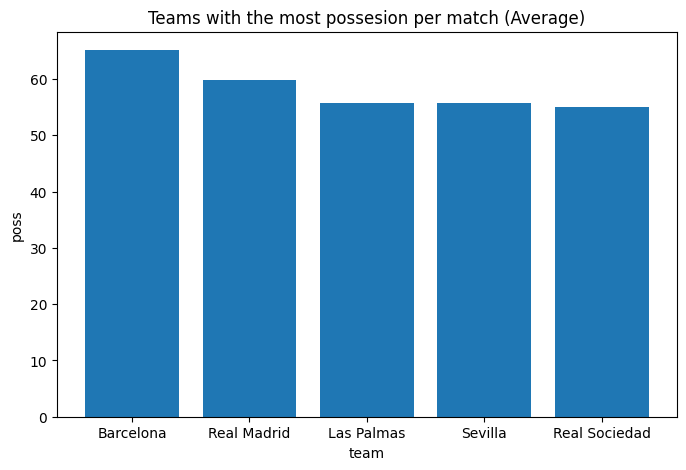

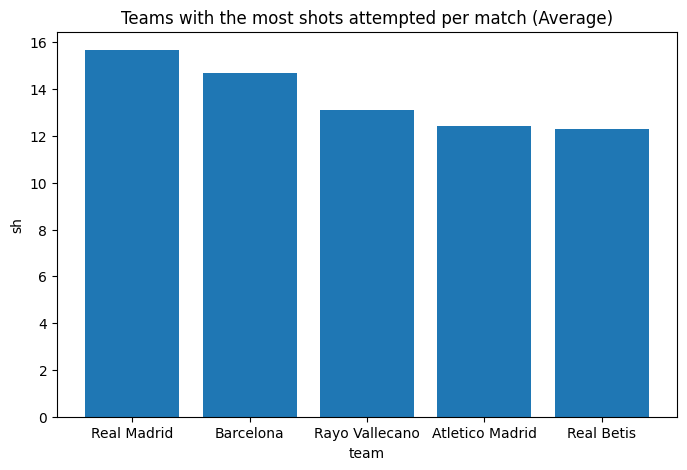

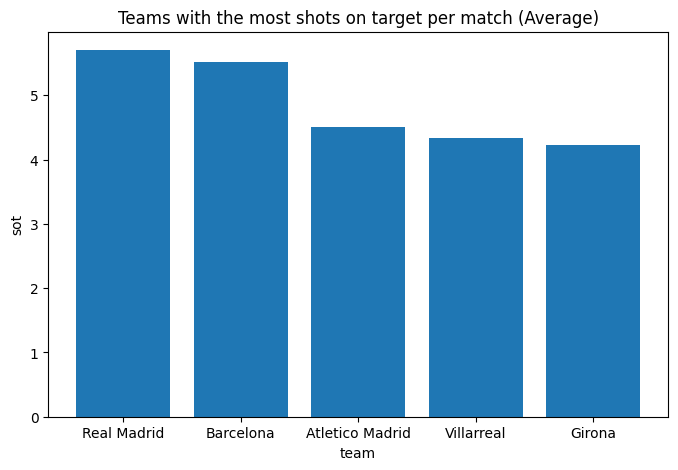

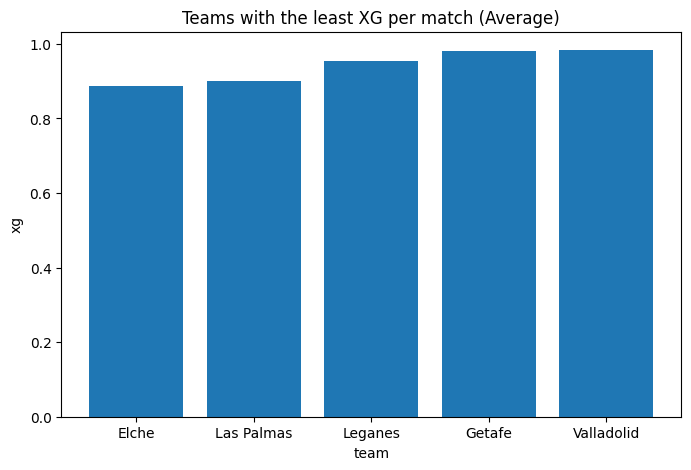

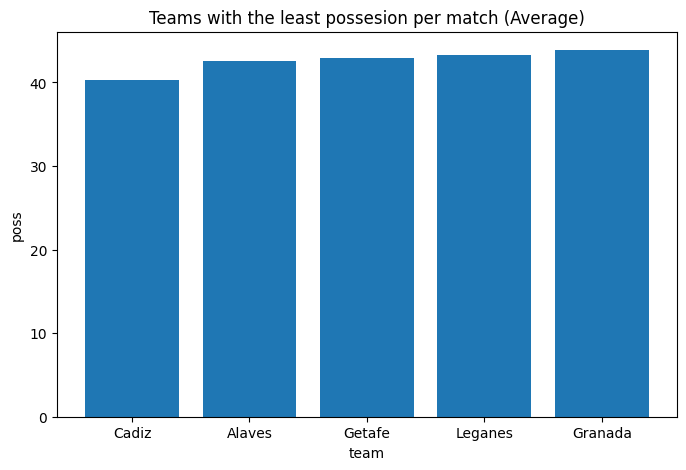

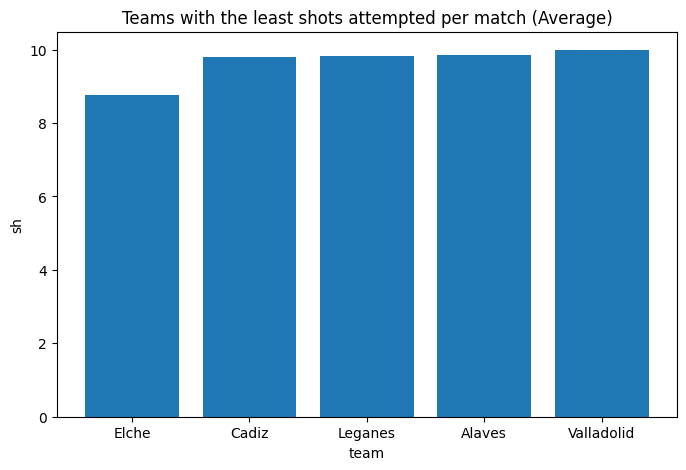

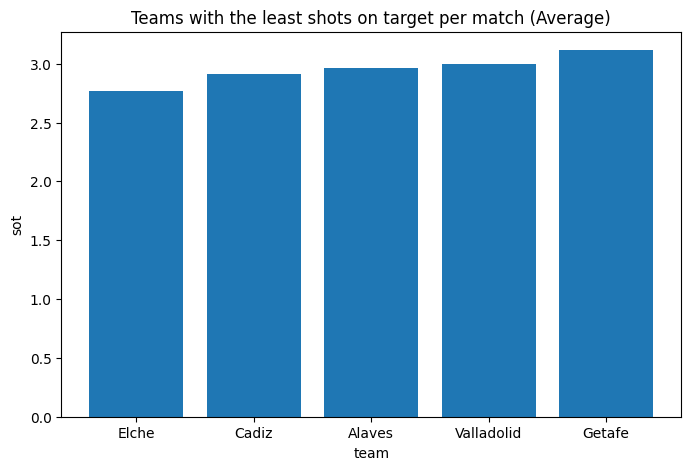

In [20]:
def get_ingame_stats(data: pd.DataFrame, stat: str, amount, ascending: bool):

    # Here instead of booleans as arguments we are going to use
    # strings to specify which column is that we want information from

    if ascending:
        stats_df = data.groupby('team')[stat].mean().reset_index().sort_values(by=stat, ascending=True)
        return stats_df[0:amount]
    else:
        stats_df = data.groupby('team')[stat].mean().reset_index().sort_values(by=stat, ascending=False)
        return stats_df[0:amount]

def plot_ingame_stats(data, stat, title):

    print()
    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.bar(x=data['team'], height=data[stat])
    plt.xlabel('team')
    plt.ylabel(stat)
    plt.show()
    print()

most_xg = get_ingame_stats(df, 'xg', 5, ascending=False)
least_xg = get_ingame_stats(df, 'xg', 5, ascending=True)
most_poss = get_ingame_stats(df, 'poss', 5, ascending=False)
least_poss = get_ingame_stats(df, 'poss', 5, ascending=True)
most_sh = get_ingame_stats(df, 'sh', 5, ascending=False)
least_sh = get_ingame_stats(df, 'sh', 5, ascending=True)
most_sot = get_ingame_stats(df, 'sot', 5, ascending=False)
least_sot = get_ingame_stats(df, 'sot', 5, ascending=True)

plot_ingame_stats(most_xg, 'xg', 'Teams with the most XG per match (Average)')
plot_ingame_stats(most_poss, 'poss', 'Teams with the most possesion per match (Average)')
plot_ingame_stats(most_sh, 'sh', 'Teams with the most shots attempted per match (Average)')
plot_ingame_stats(most_sot, 'sot', 'Teams with the most shots on target per match (Average)')
plot_ingame_stats(least_xg, 'xg', 'Teams with the least XG per match (Average)')
plot_ingame_stats(least_poss, 'poss', 'Teams with the least possesion per match (Average)')
plot_ingame_stats(least_sh, 'sh', 'Teams with the least shots attempted per match (Average)')
plot_ingame_stats(least_sot, 'sot', 'Teams with the least shots on target per match (Average)')

Now we can see which are the most frequent formations.

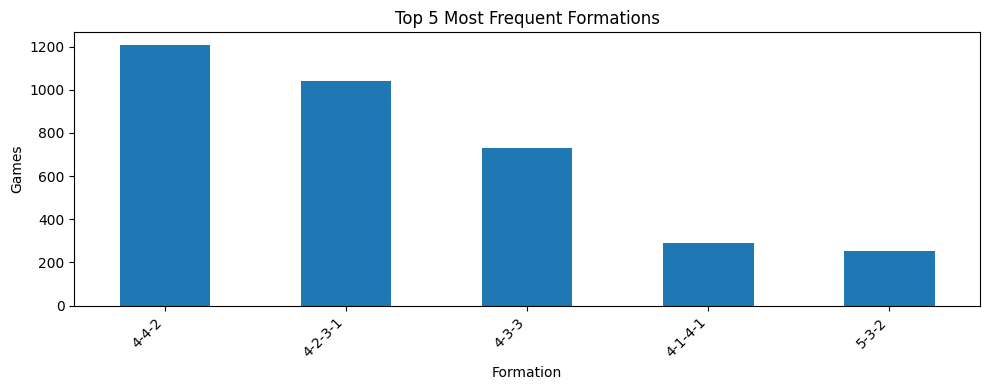

In [21]:
def plot_top_formations(data: pd.DataFrame, amount: int):
    """
    Finds the top N most frequent formations and plots them.

    Args:
        data: The pandas DataFrame containing the 'formation' column.
        amount: The number of top formations to display.
    """
    if 'formation' not in data.columns:
        print("Error: 'formation' column not found in the DataFrame.")
        return

    # Get the value counts of the 'formation' column and select the top N
    top_formations = data['formation'].value_counts().head(amount)

    # Create the bar plot
    plt.figure(figsize=(10, 4))
    top_formations.plot(kind='bar')
    plt.title(f'Top {amount} Most Frequent Formations')
    plt.xlabel('Formation')
    plt.ylabel('Games')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

# Example usage with the 'df' DataFrame and top 5 formations
plot_top_formations(df, 5)

Now we are done with the visualization part, it's time to preprocess the data to create and train a machine learning model to predict winners and losers. First let's clean the columns tha tneed to and then let's preprocess the data.

In [22]:
df['formation'].unique()

array(['4-2-3-1', '4-3-3', '4-1-4-1', '3-4-3', '5-3-2', '4-4-2', '5-4-1',
       '4-1-2-1-2◆', '4-4-1-1', '4-2-2-2', '4-5-1', '3-5-2', '3-5-1-1',
       '3-1-4-2', '3-4-3◆', '3-4-1-2', '4-1-3-2', '4-3-1-2', '3-2-4-1',
       '4-3-2-1', '4-2-4-0', '3-3-3-1'], dtype=object)

In [23]:
df['formation'] = df['formation'].str.replace('◆', '')
df['formation'] = df['formation'].replace('4-2-4-0', '4-2-4')
df['opp formation'] = df['opp formation'].replace('4-2-4-0', '4-2-4')

Cool, so that was the only column that needed to be cleaned, now the first thing we are going to do is work with the date column, my idea is to take as much information as I can of each column, so let's take the month of each date and create a new column and also create a new column that basically says if the game was played at the first part of the month (1 to 15) or if it was played at the end of the month (16 to 31).

In [24]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

def define_part(day):

    if day < 16:
        return 1
    else:
        return 0

df['part_of_month_encoded'] = df['date'].dt.day.apply(define_part)
df['part_of_month_encoded'].head()

,part_of_month_encoded
0,0
1,0
2,0
3,0
4,1


Now that we are done with the date let's go with the time column.  What I would do here is just divide into day and night, if the game started at 7pm (19:00) or after it is considered night, otherwise is day.

In [25]:
df['encoded_time'] = df['time'].str[0:2].astype(int)
df['day_night_encoded'] = (df['encoded_time'] < 17).astype(int)
df['day_night_encoded'].head()

,day_night_encoded
0,0
1,0
2,0
3,0
4,1


Now withe the round column we know that every league has a first round and a second round, the first round is from matchweek 1 to matchweek 19 and the second one is from matchweek 19 to matchweek 38, so let's divide it into first and second round.

In [26]:
df['round_encoded'] = df['round'].str.split(' ')
df['round_encoded'] = df['round_encoded'].str[-1].astype(int)
df['round_encoded'] = (df['round_encoded'] > 19).astype(int)
df['round_encoded'].head()

,round_encoded
0,0
1,0
2,0
3,0
4,0


In [27]:
df.columns

Index(['date', 'time', 'round', 'day', 'venue', 'result', 'gf', 'ga',
       'opponent', 'xg', 'xga', 'poss', 'formation', 'opp formation',
       'referee', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team',
       'month', 'part_of_month_encoded', 'encoded_time', 'day_night_encoded',
       'round_encoded'],
      dtype='object')

Now let's encode the day of the week, I will create a function to do it manually since I want to mantain an order.

In [28]:
def day_nums(day:str):
    match day:
        case 'Sun':
            return 0
        case 'Mon':
            return 1
        case 'Tue':
            return 2
        case 'Wed':
            return 3
        case 'Thu':
            return 4
        case 'Fri':
            return 5
        case 'Sat':
            return 6
        case 'Sun':
            return 7

df['day_encoded'] = df['day'].apply(day_nums)

No let's encode the venue, it is easy because it's just home or away, it is pretty easy.

In [29]:
df['venue_encoded'] = (df['venue'] == 'Home').astype(int)
df['venue_encoded'].head()

,venue_encoded
0,0
1,1
2,0
3,1
4,0


For the result (that is the target), we will just divide it into Wins or not Wins, because if we add also Draws the model will perform poorly on the draws since there is less data.

In [30]:
df['result_encoded'] = (df['result'] == 'W').astype(int)
df['result_encoded'].head()

,result_encoded
0,1
1,1
2,1
3,1
4,1


gf and ga column will remain the same. For the opponent we will assign a number for each team, so in the future we can also use these numbers for the home team, in other words, I just want the opponent and team columns to have the same number for each team.

In [31]:
df['opponent'] = df['opponent'].replace('Alavés', 'Alaves')
df['opponent'] = df['opponent'].replace('Almería', 'Almeria')
df['opponent'] = df['opponent'].replace('Atlético Madrid', 'Atletico Madrid')
df['opponent'] = df['opponent'].replace('Cádiz', 'Cadiz')
df['opponent'] = df['opponent'].replace('Betis', 'Real Betis')
df['opponent'] = df['opponent'].replace('Leganés', 'Leganes')

team_codes = {}
teams = df['opponent'].unique().tolist()
key_num = 0

for team in teams:
    team_codes[team] = key_num
    key_num += 1

df['opponent_encoded'] = df['opponent'].map(team_codes)
df['team_encoded'] = df['team'].map(team_codes)
df[['opponent_encoded', 'team_encoded']].head()

,opponent_encoded,team_encoded
0,0,19
1,1,19
2,2,19
3,3,19
4,4,19


Now let's go with the formations and do the same as we did with team and opponent.

In [32]:
formation_codes = {}
formations = df['formation'].unique().tolist()
key_num = 0

for formation in formations:
    formation_codes[formation] = key_num
    key_num += 1

df['formation_encoded'] = df['formation'].map(formation_codes)
df['opp formation_encoded'] = df['opp formation'].map(formation_codes)
df[['opp formation', 'formation']].head()

,opp formation,formation
0,4-4-2,4-2-3-1
1,4-2-3-1,4-2-3-1
2,4-4-2,4-2-3-1
3,4-1-4-1,4-3-3
4,4-2-3-1,4-2-3-1


In [33]:
df['referee_encoded'] = df['referee'].astype('category').cat.codes
df['referee_encoded'].unique()

array([-1, 13,  3, 26, 28, 12, 27, 29, 19, 21,  8,  0, 17,  4,  2, 25, 32,
       14, 23, 11, 22, 24, 18, 16,  6,  7,  5,  1, 31, 30, 15,  9, 20, 10],
      dtype=int8)

Now we can jump with the in game stats, here is the part that we can apply feature engineering principles and create new variables from the ones that already exists. So let's start by calculating the difference between Xg and Xg_away

In [34]:
df['xg_diff'] = df['xg'] - df['xga']
df['xg_diff'].head()

,xg_diff
0,2.2
1,0.8
2,1.0
3,4.2
4,0.6


Let's do the same with possesion.

In [35]:
df['poss_a'] = 100 - df['poss']
df['poss_diff'] = df['poss'] - df['poss_a']
df[['poss', 'poss_a', 'poss_diff']].head()

,poss,poss_a,poss_diff
0,63.0,37.0,26.0
1,64.0,36.0,28.0
2,64.0,36.0,28.0
3,70.0,30.0,40.0
4,55.0,45.0,10.0


Now let's create a variable that is the effective possesion, which is the posession times the xg, this is to see how dangerous the team is, and as well, we can calculate the effective away possesion to see how vulnerable the team is.

In [36]:
df['effective_possesion'] = df['poss'] * df['xg']
df['vulnerable_possesion'] = df['poss_a'] * df['xga']

df[['effective_possesion', 'vulnerable_possesion']].head()

,effective_possesion,vulnerable_possesion
0,201.6,37.0
1,115.2,36.0
2,89.6,14.4
3,329.0,15.0
4,104.5,58.5


Now let's calculate the goal difference for each match.

In [37]:
df['gf_ga_diff'] = df['gf'] - df['ga']

As we don't have the points won on the league by team, we can calculate this, for each win the team will get 3 points, for each draw

Another useful metric is calculating how many shots on target it takes for a team to score a goal, so to calculate this, we must divide the goals in favor by the shots on target, and also taking this into consideration we can add the shots efficiency by dividing the shots on target by the total shots.

In [38]:
def calculation(num, den):
    if num == 0 or den == 0:
        return 0
    else:
        return num / den

df['shooting_scoring_efficiency'] = df.apply(lambda x: calculation(x['gf'], x['sot']), axis=1)
df['shooting_efficiency'] = df.apply(lambda x: calculation(x['sot'], x['sh']), axis=1)

df[['gf', 'shooting_scoring_efficiency', 'shooting_efficiency']].head()

,gf,shooting_scoring_efficiency,shooting_efficiency
0,2.0,0.400000,0.294118
1,2.0,0.400000,0.384615
2,2.0,0.400000,0.227273
3,7.0,0.636364,0.478261
4,4.0,0.444444,0.450000


Okey, so now that I have added some new columns, we can start calculating the rolling averages for those cols that are suitable for it.

In [39]:
def get_rolling_averages(data, cols, new_cols):

    '''
    First sort the dataframe by the date, so the rolling averages can be
    calculated correctly, then using the cols selected, the function calculates
    the rolling averages for each and they add them to the original dataframe using
    the new_cols name, we have to use the dropna because the rolling averages
    eliminates "n" rows or "n" windows as you specify, so for not geting bugs
    in a future is better just to drop those null values.
    '''

    data = data.sort_values('date')
    rolling_data = data[cols].rolling(window=3, closed='left').mean()
    data[new_cols] = rolling_data
    data = data.dropna(subset=new_cols)
    return data

cols = ['gf', 'ga', 'sh', 'sot', 'fk', 'pk', 'pkatt', 'xg', 'xga', 'poss', 'xg_diff', 'poss_a', 'poss_diff', 'effective_possesion', 'vulnerable_possesion',
        'gf_ga_diff', 'shooting_scoring_efficiency', 'shooting_efficiency']

new_cols = [f'rolling_{col}' for col in cols]

# Now we apply the function using a group by using the team, with this the dataframe will be ordered by date and team.

rolling_df = df.groupby('team').apply(lambda x: get_rolling_averages(x, cols, new_cols))
rolling_df.head()

date   time        round  day venue result   gf   ga  \
team                                                                     
Alaves 4131 2019-09-15  14:00  Matchweek 4  Sun  Home      L  0.0  1.0   
       4132 2019-09-22  18:30  Matchweek 5  Sun  Away      L  0.0  2.0   
       4133 2019-09-26  21:00  Matchweek 6  Thu  Away      L  0.0  3.0   
       4134 2019-09-29  16:00  Matchweek 7  Sun  Home      W  2.0  0.0   
       4135 2019-10-05  18:30  Matchweek 8  Sat  Away      L  1.0  2.0   

                  opponent   xg  ...  rolling_xga  rolling_poss  \
team                             ...                              
Alaves 4131        Sevilla  0.8  ...     0.766667     38.000000   
       4132  Athletic Club  0.2  ...     0.766667     38.333333   
       4133  Real Sociedad  0.3  ...     1.500000     40.333333   
       4134       Mallorca  2.1  ...     2.433333     41.000000   
       4135       Valencia  1.7  ...     2.133333     46.000000   

            rolling_xg_diff rolling_poss_a rolling_poss_diff  \
team                                                           
Alaves 4131        0.000000      62.000000        -24.000000   
       4132        0.100000      61.666667        -23.333333   
       4133       -0.833333      59.666667        -19.333333   
       4134       -2.000000      59.000000        -18.000000   
       4135       -1.266667      54.000000         -8.000000   

             rolling_effective_possesion  rolling_vulnerable_possesion  \
team                                                                     
Alaves 4131                    29.200000                     47.266667   
       4132                    33.266667                     46.900000   
       4133                    26.266667                     88.300000   
       4134                    17.366667                    142.700000   
       4135                    44.766667                    123.400000   

             rolling_gf_ga_diff  rolling_shooting_scoring_efficiency  \
team                                                                   
Alaves 4131            0.333333                             0.500000   
       4132           -0.333333                             0.333333   
       4133           -1.000000                             0.333333   
       4134           -2.000000                             0.000000   
       4135           -1.000000                             0.133333   

             rolling_shooting_efficiency  
team                                      
Alaves 4131                     0.207407  
       4132                     0.133333  
       4133                     0.150000  
       4134                     0.083333  
       4135                     0.250000  

[5 rows x 62 columns]

Now it's time to choose which variables will be used as input for the model and perform a model, as well as define our train and test sets using the date to filter it.

In [40]:
inputs1 = ['part_of_month_encoded', 'encoded_time', 'day_night_encoded', 'round_encoded', 'day_encoded', 'venue_encoded',
          'result_encoded', 'opponent_encoded', 'team_encoded', 'formation_encoded', 'opp formation_encoded', 'referee_encoded',
          'rolling_gf', 'rolling_ga', 'rolling_xg', 'rolling_xga', 'rolling_poss', 'rolling_xg_diff', 'rolling_sh', 'rolling_sot',
          'rolling_fk', 'rolling_pk', 'rolling_pkatt', 'rolling_poss_a', 'rolling_poss_diff', 'rolling_effective_possesion',
          'rolling_vulnerable_possesion', 'rolling_gf_ga_diff', 'rolling_shooting_scoring_efficiency', 'rolling_shooting_efficiency']

train1 = rolling_df[rolling_df['date'] < '2024-08-01']
test1 = rolling_df[rolling_df['date'] > '2024-08-01']

X_train1, X_test1 = train1[inputs1], test1[inputs1]
y_train1, y_test1 = train1['result_encoded'], test1['result_encoded']

Now that the dataset is divided let's try a Logistic regresion first since the target value is binary and see how well it performs.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [42]:
adjusted_weight = rolling_df['result_encoded'].value_counts()[0] / rolling_df['result_encoded'].value_counts()[1]
adjusted_weight2 = rolling_df['result_encoded'].value_counts()[1] / rolling_df['result_encoded'].value_counts()[0]

In [47]:
def preprocess_data(X_train):

    scaler = StandardScaler()

    for col in X_train.columns:
        if X_train[col].dtype == float:
            scaled = scaler.fit_transform(X_train[[col]])
            X_train[col] = scaled

    return X_train

'''
    When we train this type of datasets, we shouldn't use neither linear or logistic
    regression because the inputs asume a non-linearity, when I say this I mean that
    there is not a direct a relationship between variables that when one of them grows
    another one doesn't or the two grow the same. For example if a team has low possesion
    of the ball, it could have a lot of games won or also a lot of games lost, the relationship
    is not an straight line and this models have a hard time catching them which converts them
    in a bad option.
'''

def train_random_forest(X_train, X_test, y_train):
    RF = RandomForestClassifier()

    params = {
              'n_estimators': [100, 200],
              'criterion': ['gini', 'entropy', 'log_loss'],
              'min_samples_split': [2, 3, 4],
              'max_features': ['sqrt', 'log2'],
              'class_weight': [{0:1, 1:adjusted_weight}],
              'random_state': [72]}

    Grid_Object = GridSearchCV(estimator=RF, param_grid=params, scoring='accuracy', cv=5, verbose=1)
    Grid_Object.fit(X_train, y_train)
    best_model = Grid_Object.best_estimator_
    RF_pred = best_model.predict(X_test)
    RF_pred_proba = best_model.predict(X_test)
    print(Grid_Object.best_params_)

    return RF_pred, RF_pred_proba, best_model

def evaluate_model(y_pred, y_test):
    conf_mat = confusion_matrix(y_test, y_pred)

    sns.heatmap(conf_mat, annot=True, fmt='.2f')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confussion Matrix')
    print()

    print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'class_weight': {0: 1, 1: np.float64(1.7495133030499677)}, 'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 72}

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      1.00      1.00       187

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518



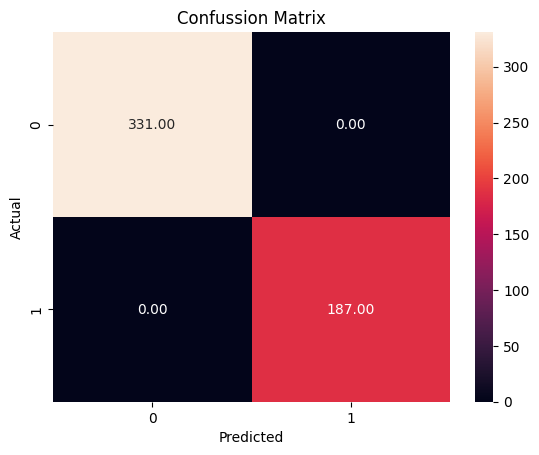

In [48]:
X_train_scaled = preprocess_data(X_train1)
RF_pred1, RF_pred1_proba, best_model1 = train_random_forest(X_train1, X_test1, y_train1)
evaluate_model(RF_pred1, y_test1)

Now this is very interesting, what's happening is that I created new variables that have information of the match when it was finished and this causes data leakage, that means that the model is cheating or it knows the answer of the result based on stats that were calculated after it, so to train a model that performs in a realistic way, some of the columns need to be dropped, especially tha ones that give information about outcomes but just in the testing set, when you want to predict a game you will not have stats like possesion, xg, xga, pk or pkatt because they hadn't happen yet. So first let's train a model without any rolling averages and see how it performs.

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'class_weight': {0: 1, 1: np.float64(1.7495133030499677)}, 'criterion': 'entropy', 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 72}

              precision    recall  f1-score   support

           0       0.65      0.85      0.74       331
           1       0.44      0.20      0.28       187

    accuracy                           0.62       518
   macro avg       0.55      0.53      0.51       518
weighted avg       0.58      0.62      0.57       518



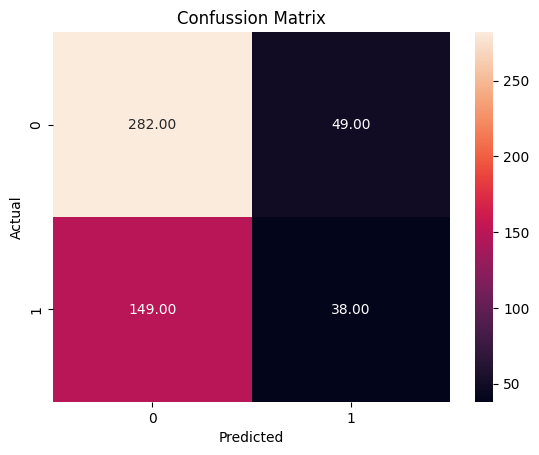

In [49]:
inputs2 = ['part_of_month_encoded', 'encoded_time', 'day_night_encoded', 'round_encoded', 'day_encoded', 'venue_encoded',
          'opponent_encoded', 'team_encoded', 'formation_encoded', 'opp formation_encoded', 'referee_encoded']

train2 = rolling_df[rolling_df['date'] < '2024-08-01']
test2 = rolling_df[rolling_df['date'] > '2024-08-01']

X_train2, X_test2 = train2[inputs2], test2[inputs2]
y_train2, y_test2 = train2['result_encoded'], test2['result_encoded']

RF_pred2, RF_pred2_proba, best_model2 = train_random_forest(X_train2, X_test2, y_train2)
evaluate_model(RF_pred2, y_test2)

Cool, so now that we have a point of reference, because of course that the model from above will not be our last model. What we are going to test now is get rid of the rolling averages and calculate an historic average of all stats that can be calculated, and in the test set we will include it just a fixed value per team of that stat from the last seasons.

In [50]:

'''
    I will explain this part of the code because it wan be confusing, this is what
    am going to do, first I will calculate an historic average for each stat, I will do that
    by using a copy of the dataframe with just the data for the seasons before the 2024-2025,
    then I calculate this using a group by team and i calculate the mean, below that I rename
    the columns just to know that those are historic averages. After that I tried the code but
    I had a bug that came from the rolling dataframe that had two level indexes so I fixed that by
    just keeping one team column. Now the datasets are ready to be merged, this merge is the same
    as the one you do in SQL with JOIN, in this case this was a left join with the historic and
    rolling datasets, and below you will see why this two tables were merged. I also did the same thing
    for the opponent so we have data from both sides in each game.
'''

historic_df = df[df['season'] < 2025].copy()

historical_team_stats = historic_df.groupby('team')[['gf', 'ga', 'xg', 'xga', 'poss', 'sh', 'sot', 'fk', 'pk', 'pkatt', 'dist', 'xg_diff', 'poss_a',
                                                     'poss_diff', 'effective_possesion', 'vulnerable_possesion', 'gf_ga_diff', 'shooting_scoring_efficiency',
                                                     'shooting_efficiency']].mean().reset_index()

historical_team_stats.rename(columns={
        'gf': 'hist_avg_gf',
        'ga': 'hist_avg_ga',
        'xg': 'hist_avg_xg',
        'xga': 'hist_avg_xga',
        'poss': 'hist_avg_poss',
        'sh': 'hist_avg_sh',
        'sot': 'hist_avg_sot',
        'fk': 'hist_avg_fk',
        'pk': 'hist_avg_pk',
        'pkatt': 'hist_avg_pkatt',
        'dist': 'hist_avg_dist',
        'xg_diff': 'hist_xg_diff',
        'poss_a': 'hist_poss_a',
        'poss_diff': 'hist_poss_diff',
        'effective_possesion': 'hist_effective_possesion',
        'vulnerable_possesion': 'hist_vulnerable_possesion',
        'gf_ga_diff': 'hist_gf_ga_diff',
        'shooting_scoring_efficiency': 'hist_shooting_scoring_efficiency',
        'shooting_efficiency': 'hist_shooting_efficiency'
}, inplace=True)

rolling_df2 = rolling_df.drop(columns=['team'], axis=1).reset_index()
rolling_df2 = rolling_df2.drop(columns=['level_1'], axis=1)

rolling_df2 = rolling_df2.merge(historical_team_stats, left_on='team', right_on='team', how='left', suffixes=('', '_team_hist'))

display(rolling_df2.head())

,team,date,time,round,day,venue,result,gf,ga,opponent,...,hist_avg_pkatt,hist_avg_dist,hist_xg_diff,hist_poss_a,hist_poss_diff,hist_effective_possesion,hist_vulnerable_possesion,hist_gf_ga_diff,hist_shooting_scoring_efficiency,hist_shooting_efficiency
0,Alaves,2019-09-15,14:00,Matchweek 4,Sun,Home,L,0.0,1.0,Sevilla,...,0.184211,17.569079,-0.289474,57.980263,-15.960526,46.048026,81.296053,-0.592105,0.326342,0.303665
1,Alaves,2019-09-22,18:30,Matchweek 5,Sun,Away,L,0.0,2.0,Athletic Club,...,0.184211,17.569079,-0.289474,57.980263,-15.960526,46.048026,81.296053,-0.592105,0.326342,0.303665
2,Alaves,2019-09-26,21:00,Matchweek 6,Thu,Away,L,0.0,3.0,Real Sociedad,...,0.184211,17.569079,-0.289474,57.980263,-15.960526,46.048026,81.296053,-0.592105,0.326342,0.303665
3,Alaves,2019-09-29,16:00,Matchweek 7,Sun,Home,W,2.0,0.0,Mallorca,...,0.184211,17.569079,-0.289474,57.980263,-15.960526,46.048026,81.296053,-0.592105,0.326342,0.303665
4,Alaves,2019-10-05,18:30,Matchweek 8,Sat,Away,L,1.0,2.0,Valencia,...,0.184211,17.569079,-0.289474,57.980263,-15.960526,46.048026,81.296053,-0.592105,0.326342,0.303665


Now let's try a model using the historic columns only.

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'class_weight': {0: 1, 1: np.float64(1.7495133030499677)}, 'criterion': 'gini', 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 72}

              precision    recall  f1-score   support

           0       0.69      0.88      0.77       331
           1       0.57      0.29      0.38       187

    accuracy                           0.67       518
   macro avg       0.63      0.58      0.58       518
weighted avg       0.65      0.67      0.63       518



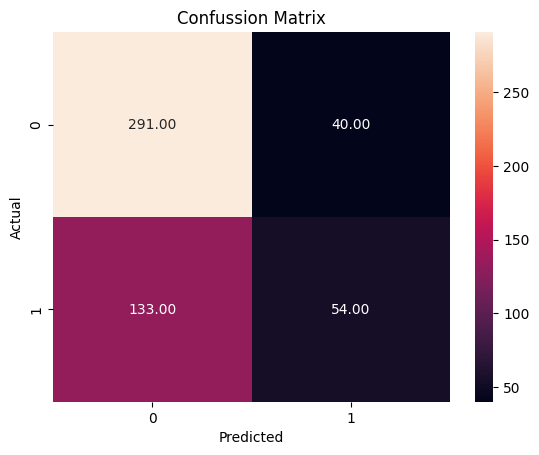

In [51]:
inputs3 = ['part_of_month_encoded', 'encoded_time', 'day_night_encoded', 'round_encoded', 'day_encoded', 'venue_encoded',
          'opponent_encoded', 'team_encoded', 'formation_encoded', 'opp formation_encoded', 'referee_encoded',
          'hist_avg_gf', 'hist_avg_ga', 'hist_avg_xg', 'hist_avg_xga', 'hist_avg_poss', 'hist_avg_sh', 'hist_avg_sot',
          'hist_avg_fk', 'hist_avg_pk', 'hist_avg_pkatt', 'hist_avg_dist', 'hist_xg_diff', 'hist_poss_a', 'hist_poss_diff',
          'hist_effective_possesion', 'hist_vulnerable_possesion', 'hist_gf_ga_diff', 'hist_shooting_scoring_efficiency', 'hist_shooting_efficiency']


train3 = rolling_df2[rolling_df2['date'] < '2024-08-01']
test3 = rolling_df2[rolling_df2['date'] > '2024-08-01']

X_train3, X_test3 = train3[inputs3], test3[inputs3]
y_train3, y_test3 = train3['result_encoded'], test3['result_encoded']

X_train_scaled = preprocess_data(X_train3)

RF_pred3, RF_pred3_proba, best_model3 = train_random_forest(X_train3, X_test3, y_train3)
evaluate_model(RF_pred3, y_test3)

The model performed a little bit better, especially at classifying wins, you can see that precision and also recall went up. Now that the dataframe contains the information for averages I can select the training and testing data. For the testing data I will just include the historic but for the training set I will add the rolling averages, and this will not cause data leakage because the testing data doesn't contain information about future outcomes, so let's see how it performs.

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'class_weight': {0: 1, 1: np.float64(1.7495133030499677)}, 'criterion': 'entropy', 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 72}

              precision    recall  f1-score   support

           0       0.68      0.86      0.76       331
           1       0.54      0.29      0.38       187

    accuracy                           0.65       518
   macro avg       0.61      0.57      0.57       518
weighted avg       0.63      0.65      0.62       518



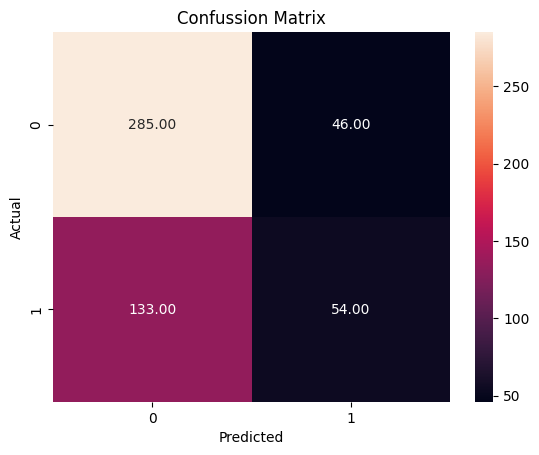

In [52]:
testing_inputs4 = ['part_of_month_encoded', 'encoded_time', 'day_night_encoded', 'round_encoded', 'day_encoded', 'venue_encoded',
                  'opponent_encoded', 'team_encoded', 'formation_encoded', 'opp formation_encoded', 'referee_encoded',
                  'hist_avg_gf', 'hist_avg_ga', 'hist_avg_xg', 'hist_avg_xga', 'hist_avg_poss', 'hist_avg_sh', 'hist_avg_sot',
                  'hist_avg_fk', 'hist_avg_pk', 'hist_avg_pkatt', 'hist_xg_diff', 'hist_poss_a', 'hist_poss_diff',
                  'hist_effective_possesion', 'hist_vulnerable_possesion', 'hist_gf_ga_diff', 'hist_shooting_scoring_efficiency',
                  'hist_shooting_efficiency']

training_inputs4 = ['part_of_month_encoded', 'encoded_time', 'day_night_encoded', 'round_encoded', 'day_encoded', 'venue_encoded',
                   'opponent_encoded', 'team_encoded', 'formation_encoded', 'opp formation_encoded', 'referee_encoded',
                   'rolling_gf', 'rolling_ga',  'rolling_xg', 'rolling_xga', 'rolling_poss', 'rolling_sh', 'rolling_sot', 'rolling_fk', 'rolling_pk',
                   'rolling_pkatt', 'rolling_xg_diff', 'rolling_poss_a', 'rolling_poss_diff', 'rolling_effective_possesion',
                   'rolling_vulnerable_possesion', 'rolling_gf_ga_diff', 'rolling_shooting_scoring_efficiency', 'rolling_shooting_efficiency']

train4 = rolling_df2[rolling_df2['date'] < '2024-08-01']
test4 = rolling_df2[rolling_df2['date'] > '2024-08-01']

X_train4, X_test4 = train4[training_inputs4], test4[testing_inputs4]
y_train4, y_test4 = train4['result_encoded'], test4['result_encoded']

X_test4.columns = training_inputs4

X_train4 = preprocess_data(X_train4)

RF_pred4, RF_pred4_proba, best_model4 = train_random_forest(X_train4, X_test4, y_train4)
evaluate_model(RF_pred4, y_test4)

Now that I have tried the same model with different calculations of the same data, the data with historical averages was the one that performed the better, so what I would do now is to try different models that doesn't asume linearity like XGBoost, SVM and Neural Networks to see if one of them performs better than the Random Forest on the data that contains the historic averages because that was the best out of all I tested.

In [46]:
from sklearn.svm import SVC

def train_SVM(X_train, y_train, X_test):

    SVM = SVC()
    params = [{'kernel': ['rbf'],
         'C': [0.01, 0.1, 1, 10],
         'gamma':[0.001, 0.01, 0.1, 1]},

        {'kernel': ['linear'],
         'C': [0.01, 0.1, 1, 10]}]

    Grid_Object = GridSearchCV(estimator=SVC(), param_grid=params, cv=5, scoring='accuracy', verbose=1)
    Grid_Object.fit(X_train, y_train)
    print(Grid_Object.best_estimator_)

    SVM_pred = Grid_Object.predict(X_test)
    return SVM_pred

Now let's train the model using the historic averages.

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVC(C=1, gamma=0.001)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       331
           1       0.36      1.00      0.53       187

    accuracy                           0.36       518
   macro avg       0.18      0.50      0.27       518
weighted avg       0.13      0.36      0.19       518



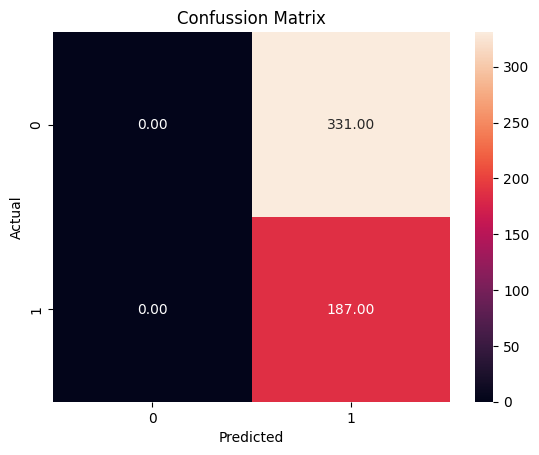

In [63]:
SVM_pred = train_SVM(X_train3, y_train3, X_test3)
evaluate_model(SVM_pred, y_test3)

The model performs pretty bad with SVM as you can see, so now let's try with the XGBoost that is basically a Random Forest but on steroids and see how well it performs. If XGBoost doesn't perform well I will try Neural Networks.


              precision    recall  f1-score   support

           0       0.66      0.99      0.79       331
           1       0.83      0.08      0.15       187

    accuracy                           0.66       518
   macro avg       0.74      0.54      0.47       518
weighted avg       0.72      0.66      0.56       518



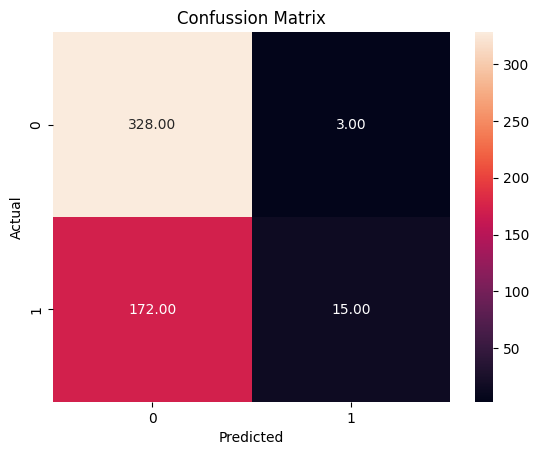

In [54]:
from xgboost import XGBClassifier

xgboost_clf = XGBClassifier()

params = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'scale_pos_weight': [adjusted_weight2]
}

grid_xgb = GridSearchCV(xgboost_clf, param_grid=params, cv=5)
grid_xgb.fit(X_train3, y_train3)
xgboost_best_model = grid_xgb.best_estimator_
xgboost_pred = xgboost_best_model.predict(X_test3)
xgboost_pred_proba = xgboost_best_model.predict_proba(X_test3)
evaluate_model(xgboost_pred, y_test3)

Honestly, in terms of real world application, this XGBoost model is probably the best one yet because as there is just wins or draw/losses, what I need is a model that is a great predictor of wins, and this one has the higher precision, also a very low recall but it is a trade-off, accuracy is the same as last models so I think this is the model that would be usefull in a case scenario. Now let's see which variables have the biggest impact on the model.

Just for comparison, let's also test the XGBoost model on the rolling averages on the training data and historic data for the testing and compare with just historic data for both, that is the modelo above.


              precision    recall  f1-score   support

           0       0.65      0.96      0.78       331
           1       0.59      0.11      0.18       187

    accuracy                           0.65       518
   macro avg       0.62      0.53      0.48       518
weighted avg       0.63      0.65      0.56       518



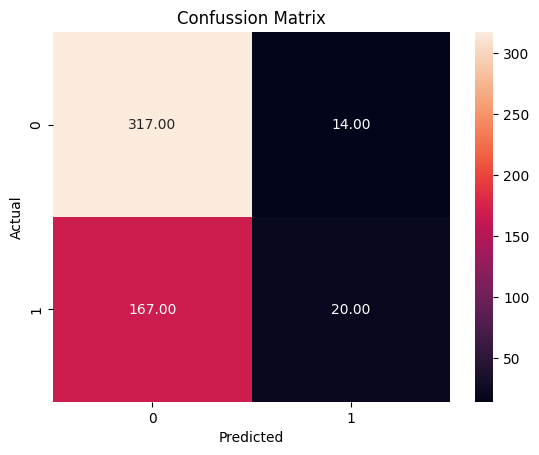

In [56]:
grid_xgb.fit(X_train4, y_train4)
xgboost_best_model2 = grid_xgb.best_estimator_
xgboost_pred2 = xgboost_best_model2.predict(X_test4)
xgboost_pred_proba2 = xgboost_best_model2.predict_proba(X_test4)
evaluate_model(xgboost_pred2, y_test4)

#Results

So this is what I found out.

- The best model for this dataset in terms of real world application was the XGBoost, it gave the best precision in terms of win predictions, that is what I was looking for, in every model I adjusted the weigth for the minoritary class on the target column that was 1, and the model that gave me the best precision was the XGBoost.

- Models like SVM are not good for this type of data.

- The model that gave the best precision in terms of wins had had a very low recall, which means that it is leaving too many games that ended up as wins out or missclassified because it want to be very sure at the time of predicting.

- Out of the 518 games from the testing data, if we just use the win class that is 1, the model just classified or predict correctly 15 games out of that 518.

- The average accuracy for a model that performs well is around 65%, so trying to predict sport games outcomes is not that easy even for robust machine learning models.

- Using historic stats gave me better results than using rolling averages on the random forest models.

Text(0.5, 1.0, 'Feature importance')

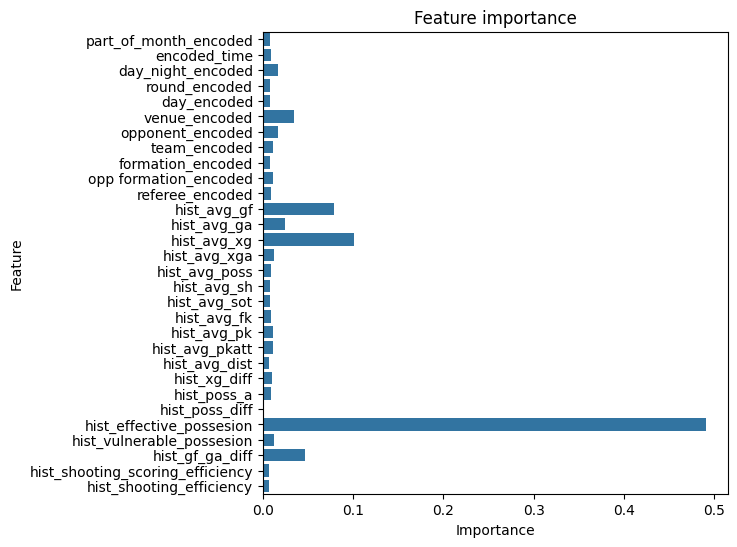

In [60]:
def plot_importances(model, feature_importances, feature_importances_names):

    plt.figure(figsize=(6, 6))
    sns.barplot(x=feature_importances , y=feature_importances_names)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Feature importance for {model}')

plot_importances('Random Forest', xgboost_best_model.feature_importances_, xgboost_best_model.feature_names_in_)

As you can see, there is probably 5 features that have a bigger impact on the model than others, the ranking goes like this:

1. Effective possesion (Posession * xg)
2. Average xg
3. Average gf (Goals scored)
4. Goals scored vs goals away difference
5. Venue. (If the game is home or away)

So now let's see the predictions and when did the model predict a win out of that 518 samples.

In [76]:
Comparing_Res = pd.DataFrame({'xgboost_pred': xgboost_pred,
                              'Actual': y_test4})

Comparing_Res_wins = Comparing_Res[Comparing_Res['xgboost_pred'] == 1]
Comparing_Res_wins_index = Comparing_Res_wins.index

#   This are the indexes in which the model predicted a win, so let's see in which
#   games and in which conditions the model predicted the wins

rolling_df2.iloc[Comparing_Res_wins_index, :][['team', 'venue', 'opponent', 'hist_avg_gf', 'hist_avg_xg', 'hist_effective_possesion', 'hist_gf_ga_diff']]

,team,venue,opponent,hist_avg_gf,hist_avg_xg,hist_effective_possesion,hist_gf_ga_diff
444,Athletic Club,Home,Espanyol,1.252632,1.266316,64.015263,0.221053
459,Athletic Club,Home,Valladolid,1.252632,1.266316,64.015263,0.221053
664,Atletico Madrid,Home,Getafe,1.700000,1.517368,77.231053,0.800000
669,Atletico Madrid,Home,Mallorca,1.700000,1.517368,77.231053,0.800000
882,Barcelona,Home,Alaves,2.042105,1.874211,122.277895,1.105263
1868,Girona,Home,Espanyol,1.881579,1.596053,87.967105,0.552632
1878,Girona,Home,Getafe,1.881579,1.596053,87.967105,0.552632
2464,Mallorca,Home,Girona,0.960526,1.027632,46.284868,-0.453947
3228,Real Madrid,Home,Espanyol,1.994737,1.821579,109.745789,1.226316
3229,Real Madrid,Home,Alaves,1.994737,1.821579,109.745789,1.226316


So if you follow LaLiga you know that a big part of this predicted outcomes were a little obvious, for example Real Madrid against Alaves at home, you know that there is a very low chance that Real Madrid could lose, so in my opinion the model is identifying the games that are easy to predict.

One of the things that is the best from this model is that it gave me the features that has the more relevance, and let's say I want to predict LaLiga games for the 2025/26 season, I already know that effective possesion, the venu, average xg, goals scored and goals scored and conceded difference will give me the best information to predict, another features that could also be crutial could be is if the game started at day or night, the average goals conceded and the average vulnerable posession. If I was going to try to predict a complete season, I can use the rolling averages of last 3 games of that current season.  